使用デバイス: cuda
Hybrid_CNN5_FC の重みを読み込みました。

テストデータ全件の評価を開始します... (モデル: Hybrid_CNN5_FC, Top-K: 130)
評価が完了しました。

[自動しきい値設定: F1スコア最大化]
-> 最適しきい値: 0.8663 (Max F1: 0.9677)

--- 定量評価結果 (Hybrid_CNN5_FC) ---
設定閾値: 0.8663
正解率 (Accuracy)  : 93.98%
適合率 (Precision) : 98.33%
再現率 (Recall)    : 93.65%
F値 (F1-score)     : 95.93%



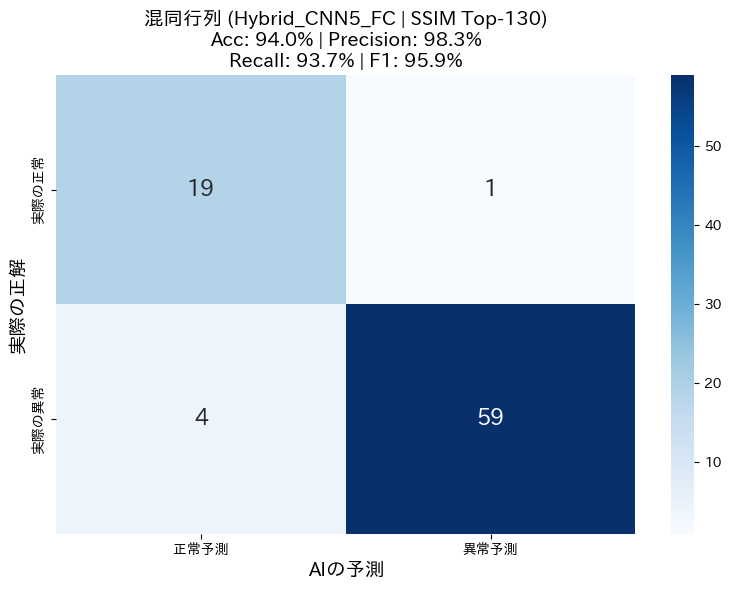

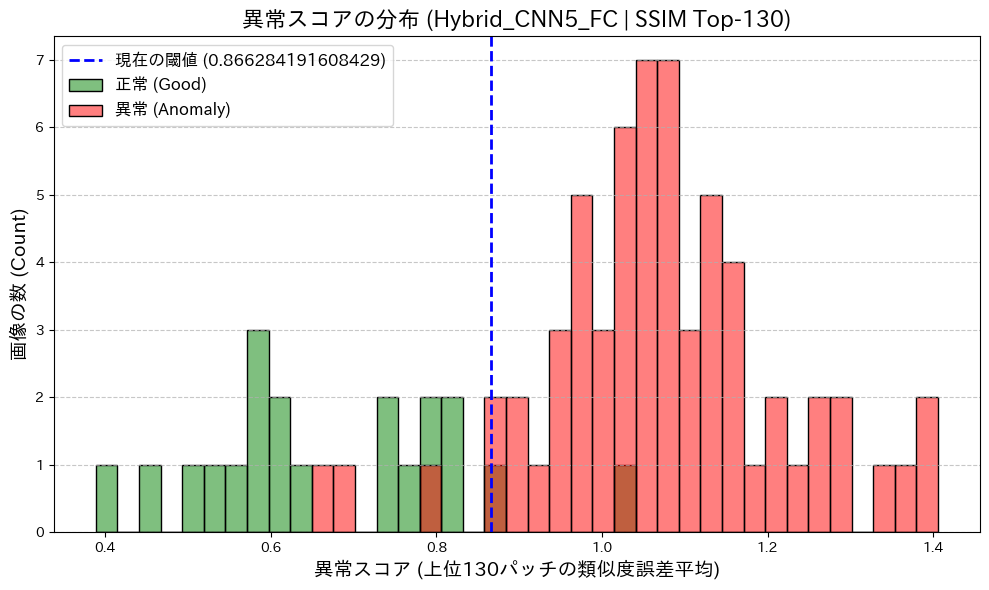


--- パターン別の代表例を可視化します ---

【1. TN: 正常を「正常」と正しく判断】 : 該当 19 件中 2 件を表示


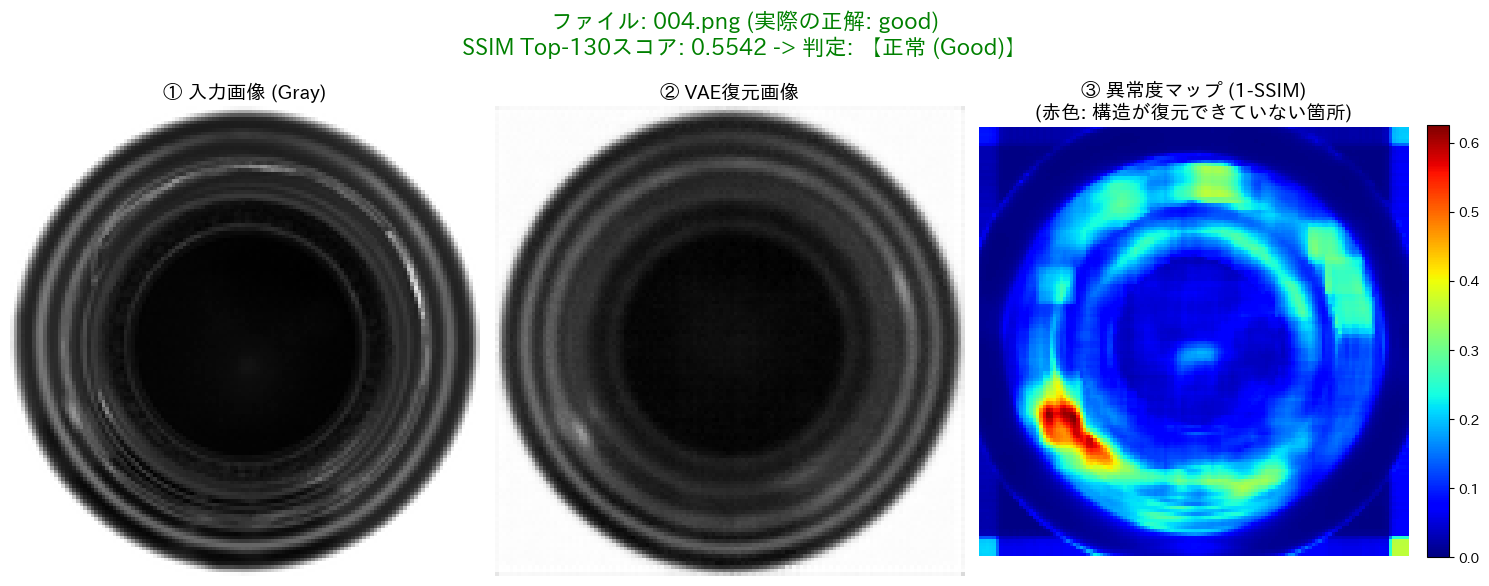

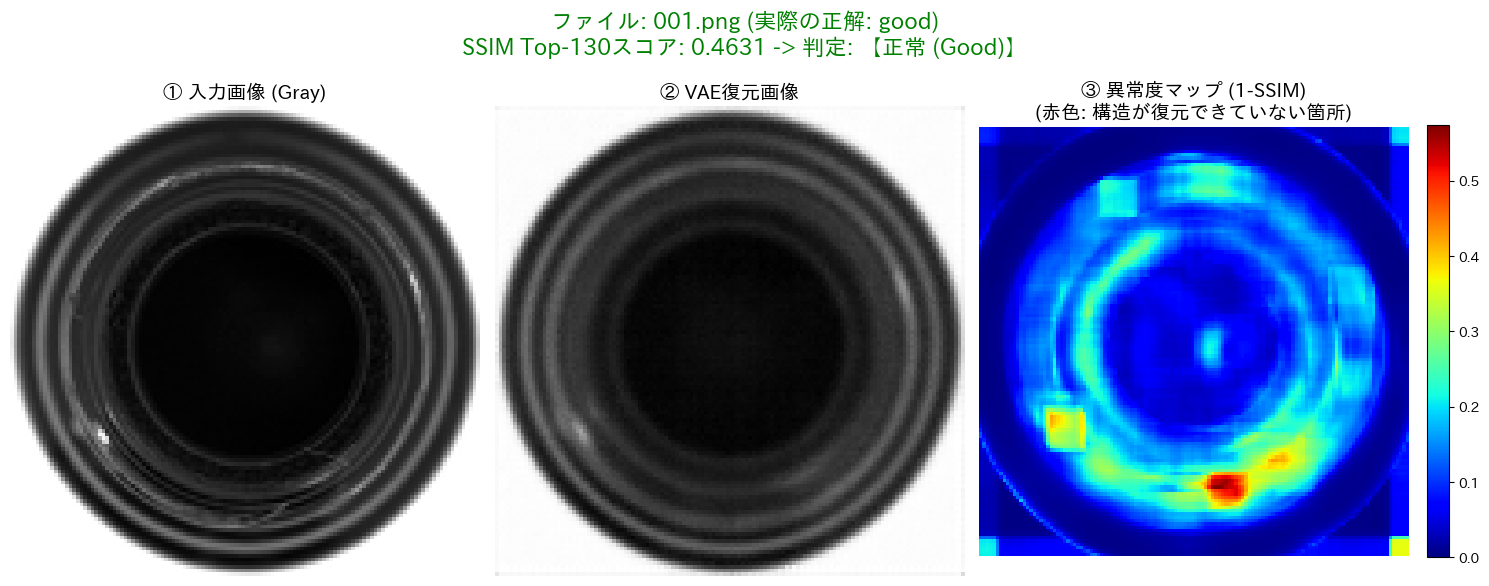


【2. FP: 正常を「異常」と誤って判断 (過剰検知)】 : 該当 1 件中 1 件を表示


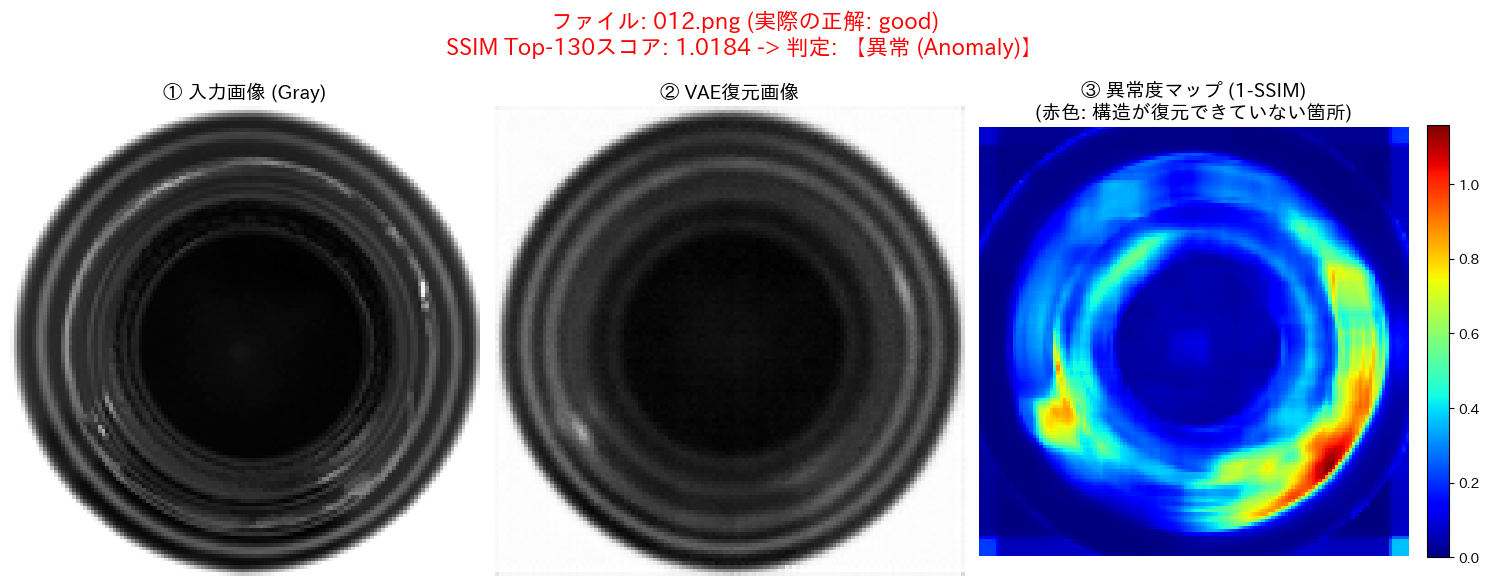


【3. FN: 異常を「正常」と誤って判plt.ylim(1e-3, 1e5)断 (見逃し)】 : 該当 4 件中 2 件を表示


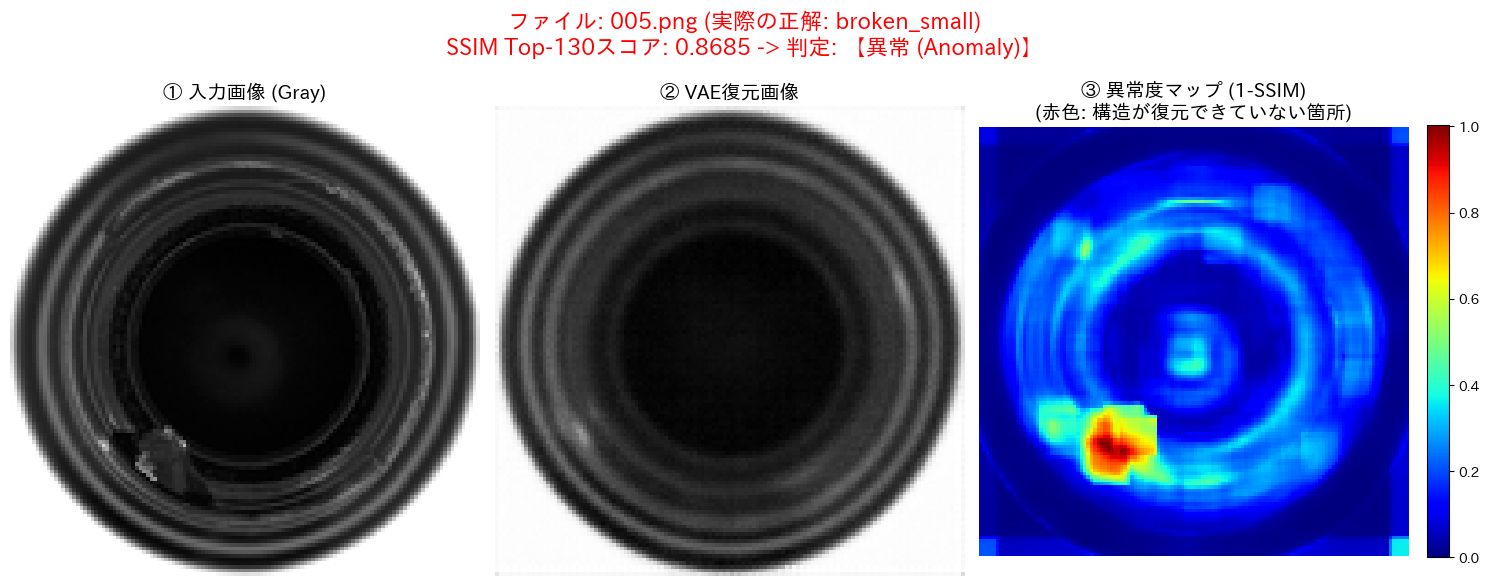

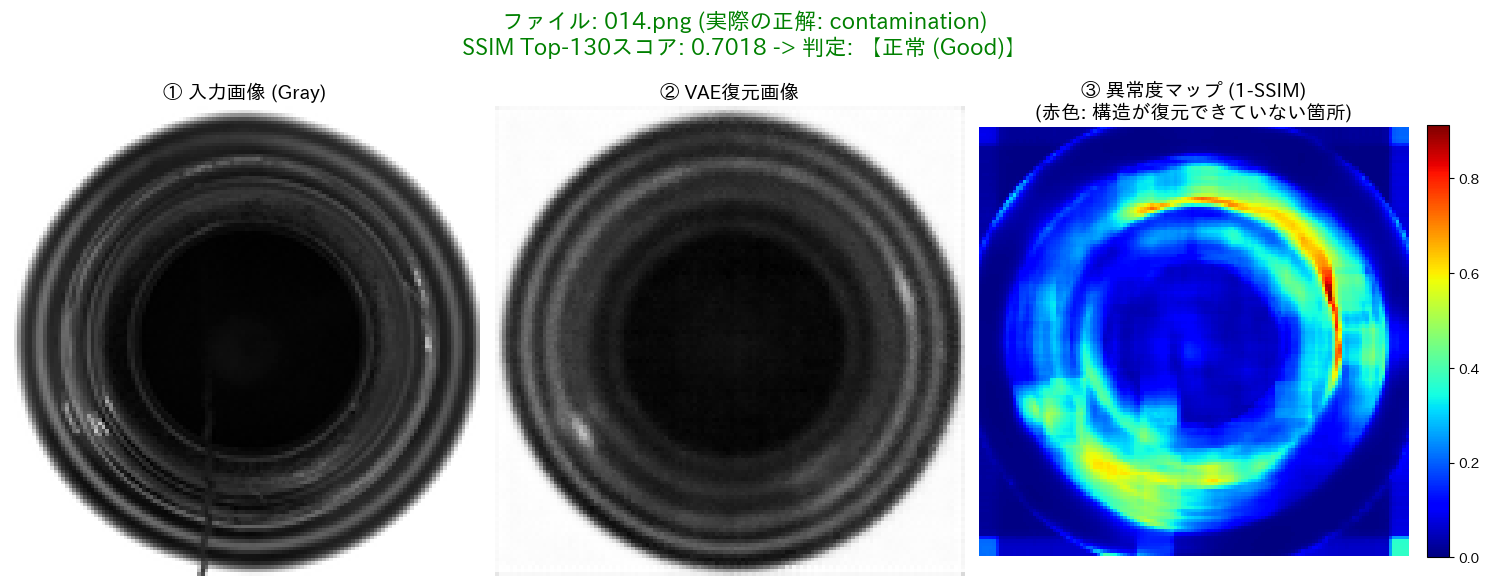


【4. TP: 異常を「異常」と正しく判断】 : 該当 59 件中 2 件を表示


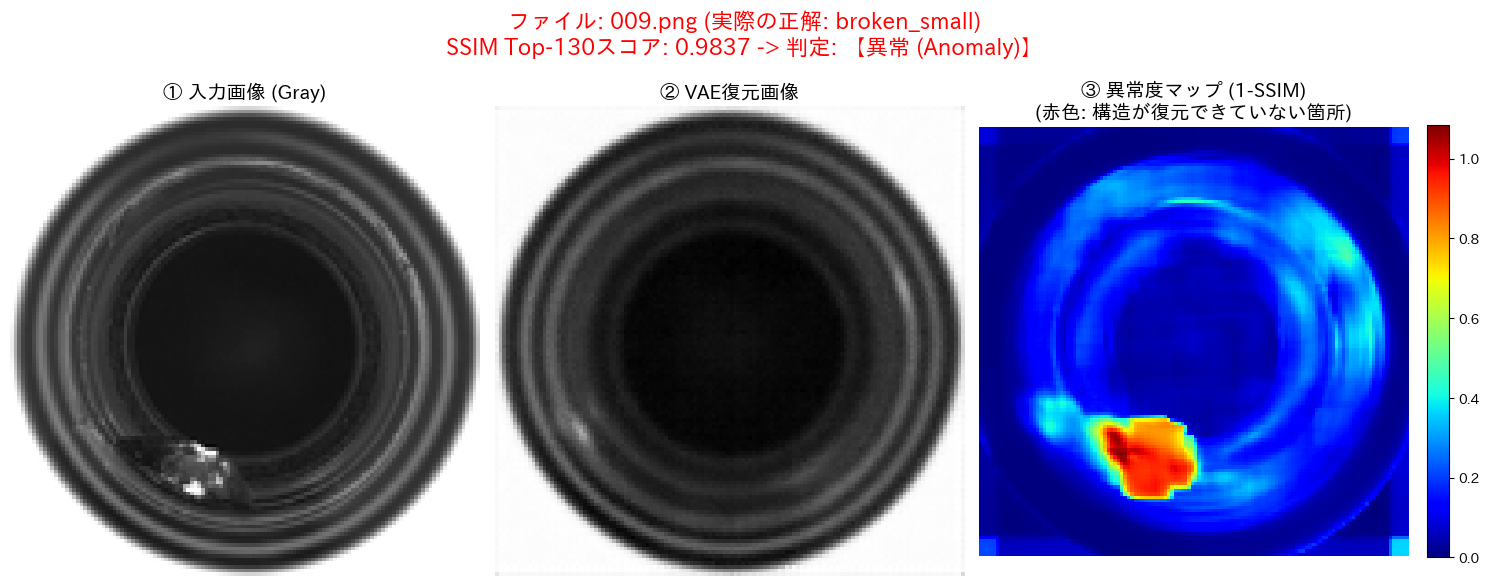

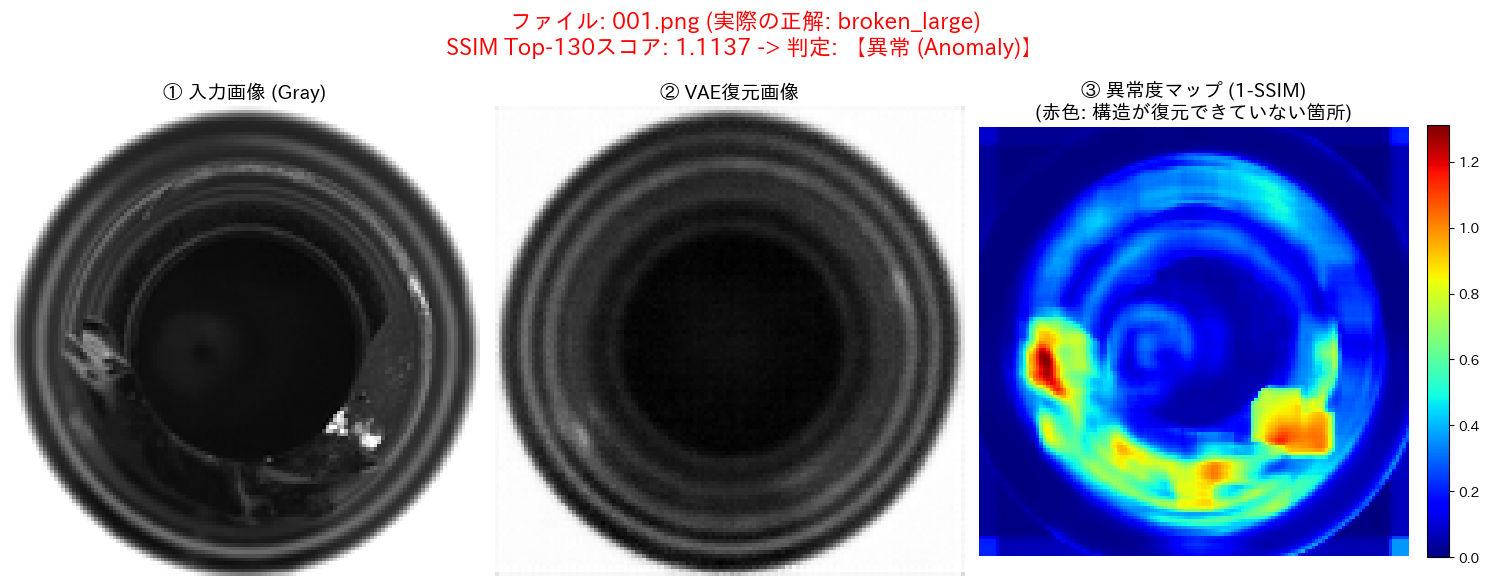


すべての検証プロセスが完了しました。


In [ ]:

# =====================================================================
# 検証用コード: ハイブリッドモデル（Hybrid_CNN5_FC）100epアニーリング版 専用
# 異常スコア: SSIM Top-K (上位130パッチの平均誤差)
# 閾値計算：F1スコアを最大化するような閾値
# =====================================================================
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import precision_recall_curve
import random
from skimage.metrics import structural_similarity as ssim

# 文字化け対策の強制適用
import japanize_matplotlib
japanize_matplotlib.japanize()

# =====================================================================
# 1. 前処理とモデルの定義 (Hybrid_CNN5_FC版)
# =====================================================================
# 学習時と同じ前処理を定義
transform = transforms.Compose([
    transforms.CenterCrop(820),
    transforms.Resize((128, 128), interpolation=transforms.InterpolationMode.LANCZOS),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
])

# 検証対象のモデルクラス定義 (学習コードからコピー)
class VAE_Hybrid_CNN_FC(nn.Module):
    def __init__(self, latent_dim=64):
        super(VAE_Hybrid_CNN_FC, self).__init__()
        
        # -------------------------------------------------------------
        # 【エンコーダ前半】 CNN_Deep5（空間圧縮: 128x128 -> 4x4）
        # -------------------------------------------------------------
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(16), nn.ReLU(),
            
            nn.Conv2d(16, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),

            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256), nn.ReLU()
        )
        
        # -------------------------------------------------------------
        # 【エンコーダ後半】 FC_Only（段階的圧縮: 4096次元 -> 128次元）
        # -------------------------------------------------------------
        self.encoder_fc = nn.Sequential(
            nn.Linear(256 * 4 * 4, 1024), nn.ReLU(),
            nn.Linear(1024, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU()
        )
        
        # 潜在空間へのマッピング（128次元 -> 64次元）
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)
        
        # -------------------------------------------------------------
        # 【デコーダ前半】 FC_Only（段階的復元: 64次元 -> 4096次元）
        # -------------------------------------------------------------
        self.decoder_fc = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, 1024), nn.ReLU(),
            nn.Linear(1024, 256 * 4 * 4), nn.ReLU()
        )
        
        # -------------------------------------------------------------
        # 【デコーダ後半】 CNN_Deep5（空間復元: 4x4 -> 128x128）
        # -------------------------------------------------------------
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),

            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(16), nn.ReLU(),
            
            nn.ConvTranspose2d(16, 1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # 1. CNNによる特徴抽出
        h = self.encoder_conv(x)
        h = torch.flatten(h, start_dim=1)
        
        # 2. FCによる段階的圧縮
        h = self.encoder_fc(h)
        
        # 3. 潜在変数の計算と安全装置（クランプ）
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        logvar = torch.clamp(logvar, min=-10.0, max=10.0)
        
        std = torch.exp(0.5 * logvar)
        z = mu + torch.randn_like(std) * std
        
        # 4. FCによる段階的復元
        h_recon = self.decoder_fc(z)
        h_recon = h_recon.view(-1, 256, 4, 4) # 4階テンソルに戻す
        
        # 5. CNNによる画像復元
        recon = self.decoder_conv(h_recon)
        
        return recon, mu, logvar

# =====================================================================
# 2. 評価と可視化の関数群 (SSIM Top-K仕様)
# =====================================================================
def evaluate_dataset(model, test_dir, device, top_k=130): # 【修正1】引数から threshold を削除
    """データセット全体を推論し、評価指標、スコア、ファイルパスを返す"""
    model.eval()
    
    # 【修正2】y_pred をリストから削除
    y_true, scores, all_image_paths = [], [], [] 
    
    test_dir = Path(test_dir)
    if not test_dir.exists():
        raise FileNotFoundError(f"テストディレクトリが見つかりません: {test_dir}\n研究室PCのデータパスを確認してください。")

    print(f"テストデータ全件の評価を開始します... (モデル: Hybrid_CNN5_FC, Top-K: {top_k})")
    
    with torch.no_grad():
        for folder in test_dir.iterdir():
            if not folder.is_dir():
                continue
                
            true_label = 0 if folder.name == "good" else 1
            
            img_paths = list(folder.glob("*.png"))
            if not img_paths:
                continue

            for img_path in img_paths:
                img = Image.open(img_path).convert('RGB')
                input_tensor = transform(img).unsqueeze(0).to(device)

                recon_tensor, _, _ = model(input_tensor)

                input_img = input_tensor.squeeze().cpu().numpy()
                recon_img = recon_tensor.squeeze().cpu().numpy()

                _, ssim_map = ssim(input_img, recon_img, data_range=1.0, win_size=11, full=True)
                anomaly_map = 1.0 - ssim_map

                sorted_anomaly = np.sort(anomaly_map.flatten())[::-1]
                top_k_score = np.mean(sorted_anomaly[:top_k])

                # 【修正3】 pred_label = ... の行を丸ごと削除

                y_true.append(true_label)
                # 【修正4】 y_pred.append(pred_label) の行を丸ごと削除
                scores.append(top_k_score)
                all_image_paths.append(img_path)

    print("評価が完了しました。")
    
    # 【修正5】戻り値から np.array(y_pred) を削除し、3つだけ返すように変更
    return np.array(y_true), np.array(scores), all_image_paths

def plot_confusion_matrix(y_true, y_pred, threshold, top_k=130):
    """混同行列と定量評価指標(正解率・適合率・再現率・F値)を描画する"""
    acc = accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"\n--- 定量評価結果 (Hybrid_CNN5_FC) ---")
    print(f"設定閾値: {threshold:.4f}")
    print(f"正解率 (Accuracy)  : {acc * 100:.2f}%")
    print(f"適合率 (Precision) : {precision * 100:.2f}%")
    print(f"再現率 (Recall)    : {recall * 100:.2f}%")
    print(f"F値 (F1-score)     : {f1 * 100:.2f}%\n")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6)) # タイトルが長くなるため横幅を少し拡大
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['正常予測', '異常予測'],
                yticklabels=['実際の正常', '実際の異常'],
                annot_kws={"size": 16})

    # タイトルに4つの指標をすべて表示
    title_str = (f"混同行列 (Hybrid_CNN5_FC | SSIM Top-{top_k})\n"
                 f"Acc: {acc*100:.1f}% | Precision: {precision*100:.1f}%\n"
                 f"Recall: {recall*100:.1f}% | F1: {f1*100:.1f}%")
    
    plt.title(title_str, fontsize=14)
    plt.xlabel('AIの予測', fontsize=14)
    plt.ylabel('実際の正解', fontsize=14)
    plt.tight_layout()
    plt.show()

def plot_score_distribution(y_true, scores, threshold, top_k=130):
    """正常画像と異常画像の異常スコア分布(ヒストグラム)を描画する"""
    plt.figure(figsize=(10, 6))

    normal_scores = scores[y_true == 0]
    anomaly_scores = scores[y_true == 1]

    min_score = np.min(scores)
    max_score = np.max(scores)
    common_bins = np.linspace(min_score, max_score, 40)

    sns.histplot(normal_scores, bins=common_bins, color='green', alpha=0.5, label='正常 (Good)', kde=False)
    sns.histplot(anomaly_scores, bins=common_bins, color='red', alpha=0.5, label='異常 (Anomaly)', kde=False)

    plt.axvline(x=threshold, color='blue', linestyle='--', linewidth=2, label=f'現在の閾値 ({threshold})')

    plt.title(f"異常スコアの分布 (Hybrid_CNN5_FC | SSIM Top-{top_k})", fontsize=16, fontweight='bold')
    plt.xlabel(f"異常スコア (上位{top_k}パッチの類似度誤差平均)", fontsize=14)
    plt.ylabel("画像の数 (Count)", fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

def plot_single_anomaly(model, image_path, device, threshold, top_k=130):
    """1枚の画像を3パネルで可視化する"""
    model.eval()
    img = Image.open(image_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        recon_tensor, _, _ = model(input_tensor)

    input_img = input_tensor.squeeze().cpu().numpy()
    recon_img = recon_tensor.squeeze().cpu().numpy()

    _, ssim_map = ssim(input_img, recon_img, data_range=1.0, win_size=11, full=True)
    anomaly_map = 1.0 - ssim_map
    sorted_anomaly = np.sort(anomaly_map.flatten())[::-1]
    top_k_score = np.mean(sorted_anomaly[:top_k])

    is_anomaly = top_k_score > threshold
    judgment = "【異常 (Anomaly)】" if is_anomaly else "【正常 (Good)】"
    result_color = 'red' if is_anomaly else 'green'

    fig, axes = plt.subplots(1, 3, figsize=(15, 6))
    fig.suptitle(f"ファイル: {image_path.name} (実際の正解: {image_path.parent.name})\nSSIM Top-{top_k}スコア: {top_k_score:.4f} -> 判定: {judgment}",
                 fontsize=16, fontweight='bold', color=result_color)

    axes[0].imshow(input_img, cmap='gray')
    axes[0].set_title("① 入力画像 (Gray)", fontsize=14)
    axes[0].axis('off')

    axes[1].imshow(recon_img, cmap='gray')
    axes[1].set_title("② VAE復元画像", fontsize=14)
    axes[1].axis('off')

    vmax_val = np.max(anomaly_map) if np.max(anomaly_map) > 0.1 else 0.1
    im3 = axes[2].imshow(anomaly_map, cmap='jet', vmin=0, vmax=vmax_val)
    axes[2].set_title(f"③ 異常度マップ (1-SSIM)\n(赤色: 構造が復元できていない箇所)", fontsize=14)
    axes[2].axis('off')
    fig.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

def compute_optimal_threshold_f1(y_true, scores):
    """PR曲線からF1スコアが最大となるしきい値を自動計算する"""
    precisions, recalls, thresholds = precision_recall_curve(y_true, scores)
    
    # F1スコアの計算 (分母が0になるのを防ぐため 1e-10 を足しています)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    
    # F1スコアが最大になるインデックスを取得
    optimal_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[optimal_idx]
    
    print(f"\n[自動しきい値設定: F1スコア最大化]")
    print(f"-> 最適しきい値: {optimal_threshold:.4f} (Max F1: {f1_scores[optimal_idx]:.4f})")
    
    return optimal_threshold

# =====================================================================
# 3. 実行ブロック (研究室PCでの実行用)
# =====================================================================
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"使用デバイス: {device}")

    # -------------------------------------------------------------
    # ★ モデルと重みファイルの指定 ★
    # -------------------------------------------------------------
    model = VAE_Hybrid_CNN_FC(latent_dim=64).to(device)

    # 学習コードで設定したファイル名に合わせる
    MODEL_PATH = "/home/okoshi/my_GItHub/image-anomaly-detection/saved_models/vae_Hybrid_CNN5_FC_Annealing_ep100_beta50_128.pth"

    if not Path(MODEL_PATH).exists():
        raise FileNotFoundError(f"重みファイルが見つかりません: {MODEL_PATH}\n学習が完了しているか、パスが正しいか確認してください。")

    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    print(f"Hybrid_CNN5_FC の重みを読み込みました。\n")

    # -------------------------------------------------------------
    # ★ テストデータのパス設定 ★
    # -------------------------------------------------------------
    TEST_DIR = "/home/okoshi/my_GItHub/image-anomaly-detection/data/bottle/test"

    # -------------------------------------------------------------
    # ★ 検証パラメータの設定 ★
    # -------------------------------------------------------------
    TOP_K = 130
    # THRESHOLD = 0.9
    # -------------------------------------------------------------
    # 検証プロセスの実行
    # -------------------------------------------------------------

    # 1. まず全画像の異常スコアを算出（y_predを受け取らない、THRESHOLDを渡さない）
    y_true, scores, all_image_paths = evaluate_dataset(model, TEST_DIR, device, top_k=TOP_K)

    # 2. F1スコアが最大になるようにしきい値を自動計算
    THRESHOLD = compute_optimal_threshold_f1(y_true, scores)

    # 3. 決定したしきい値を用いて予測ラベル(y_pred)を作成
    y_pred = (scores > THRESHOLD).astype(int)

    # 4. グラフの描画
    plot_confusion_matrix(y_true, y_pred, THRESHOLD, top_k=TOP_K)
    plot_score_distribution(y_true, scores, THRESHOLD, top_k=TOP_K)

    print("\n--- パターン別の代表例を可視化します ---")
    tn_paths, fp_paths, fn_paths, tp_paths = [], [], [], []
    for true_lbl, pred_lbl, path in zip(y_true, y_pred, all_image_paths):
        if true_lbl == 0 and pred_lbl == 0: tn_paths.append(path)
        elif true_lbl == 0 and pred_lbl == 1: fp_paths.append(path)
        elif true_lbl == 1 and pred_lbl == 0: fn_paths.append(path)
        elif true_lbl == 1 and pred_lbl == 1: tp_paths.append(path)

    categories = {
        "【1. TN: 正常を「正常」と正しく判断】": tn_paths,
        "【2. FP: 正常を「異常」と誤って判断 (過剰検知)】": fp_paths,
        "【3. FN: 異常を「正常」と誤って判plt.ylim(1e-3, 1e5)断 (見逃し)】": fn_paths,
        "【4. TP: 異常を「異常」と正しく判断】": tp_paths
    }

    for title, paths in categories.items():
        sample_size = min(2, len(paths))
        print(f"\n{title} : 該当 {len(paths)} 件中 {sample_size} 件を表示")

        if sample_size > 0:
            sampled_paths = random.sample(paths, sample_size)
            for img_path in sampled_paths:
                plot_single_anomaly(model, img_path, device, THRESHOLD, top_k=TOP_K)
        else:
            print("  -> このパターンに該当する画像はありません。")

    print("\nすべての検証プロセスが完了しました。")

使用デバイス: cuda
Hybrid_CNN5_FC の重みを読み込みました。

テストデータ全件の評価を開始します... (モデル: Hybrid_CNN5_FC, Top-K: 130)
評価が完了しました。

[教師なししきい値設定: パーセンタイル法 (95.0%)]
-> 正常データの 95.0% を正常とみなす
-> 最適しきい値: 0.8754

--- 定量評価結果 (Hybrid_CNN5_FC) ---
設定閾値: 0.8754
正解率 (Accuracy)  : 92.77%
適合率 (Precision) : 98.31%
再現率 (Recall)    : 92.06%
F値 (F1-score)     : 95.08%



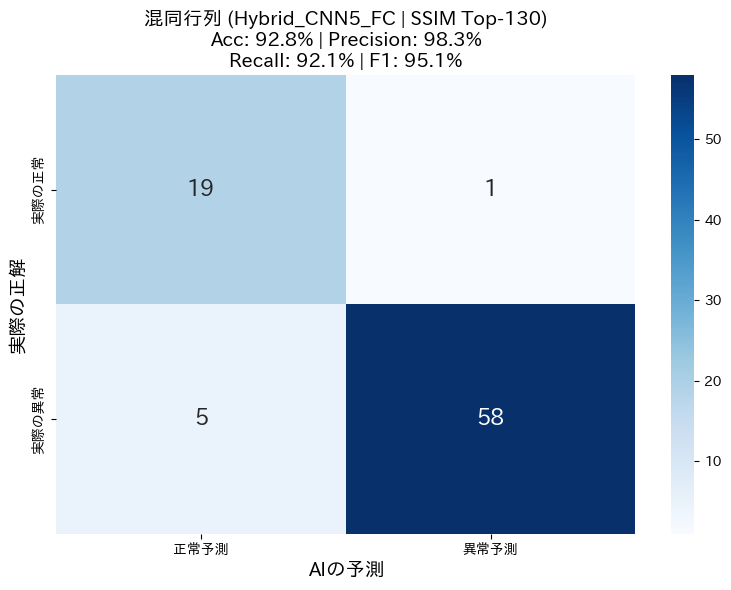

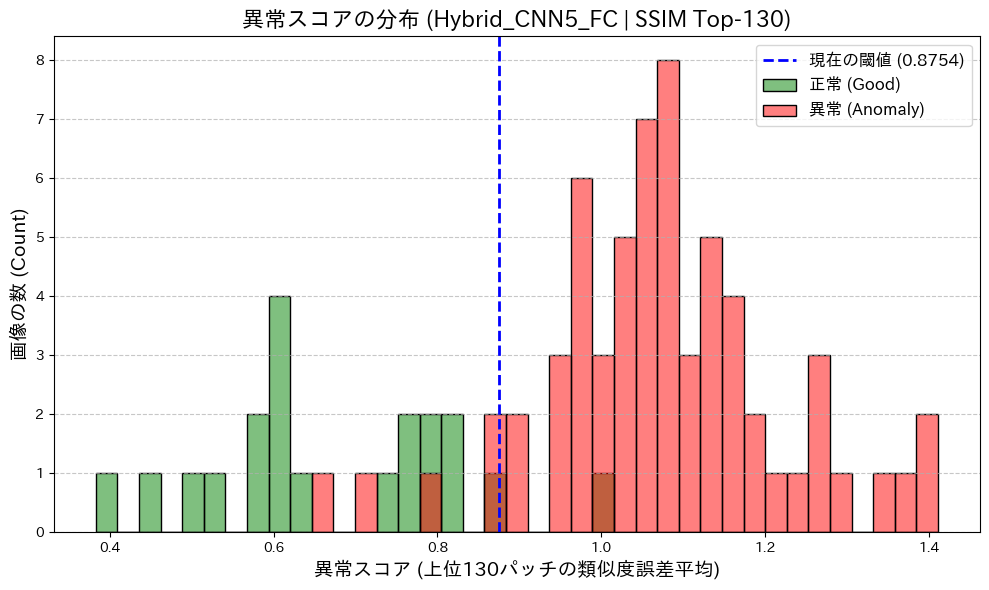

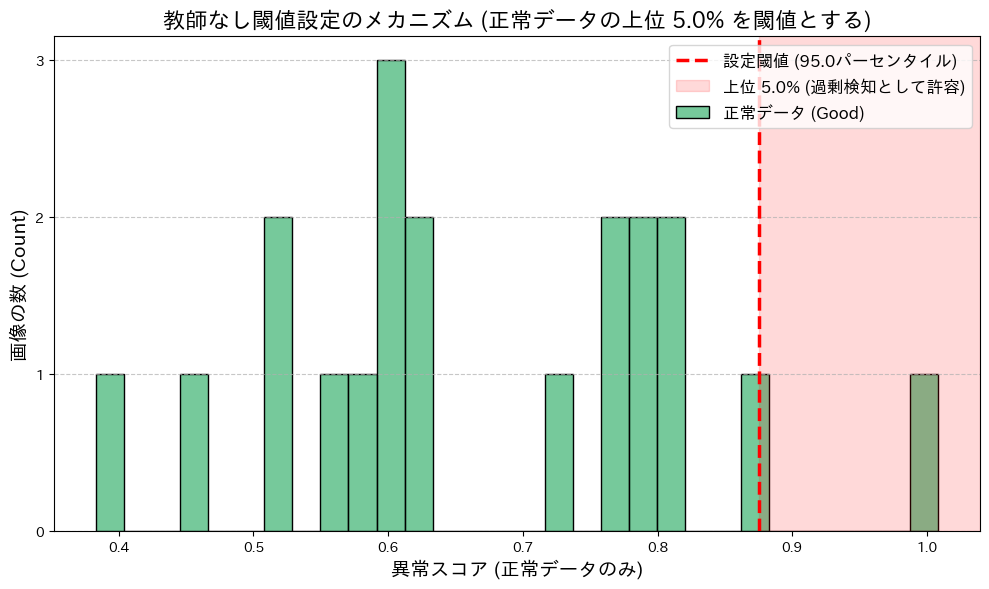


--- パターン別の代表例を可視化します ---

【1. TN: 正常を「正常」と正しく判断】 : 該当 19 件中 2 件を表示


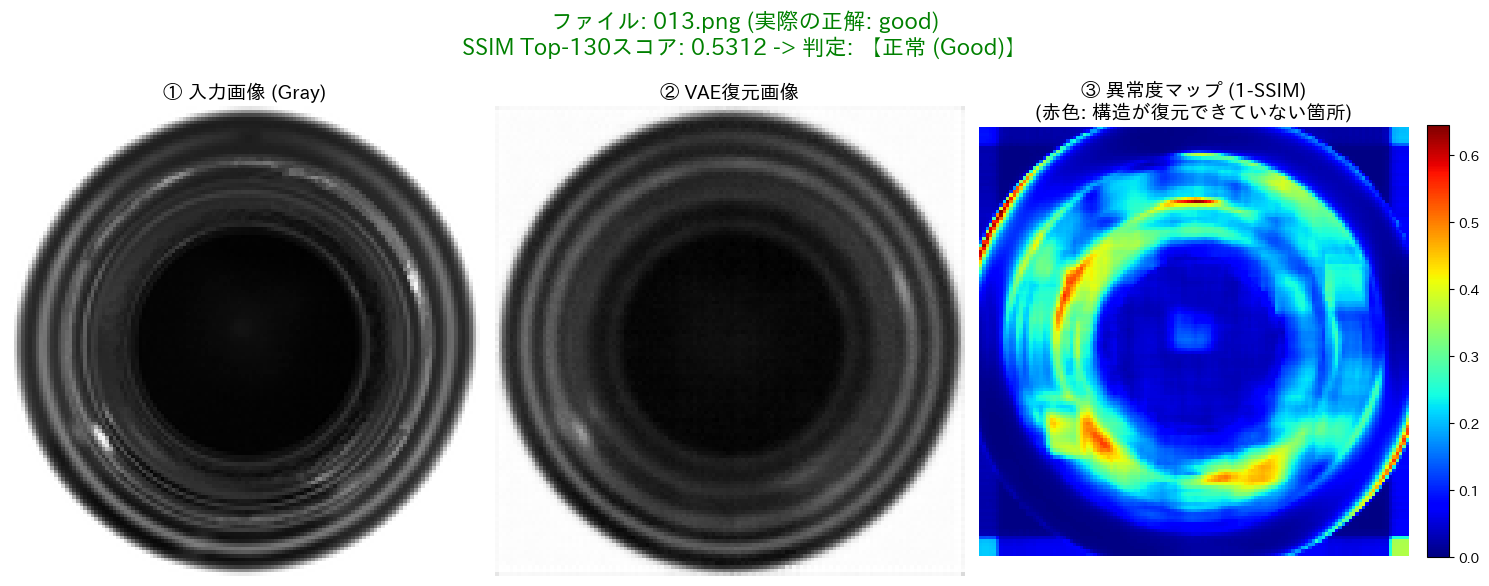

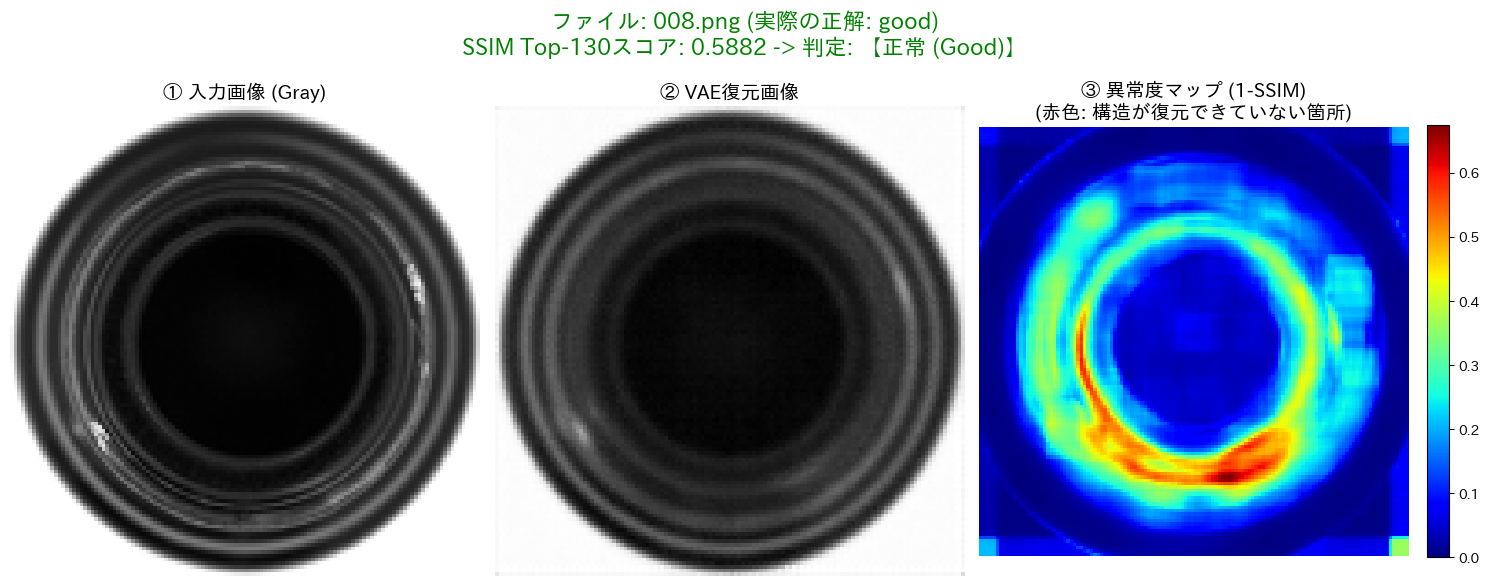


【2. FP: 正常を「異常」と誤って判断 (過剰検知)】 : 該当 1 件中 1 件を表示


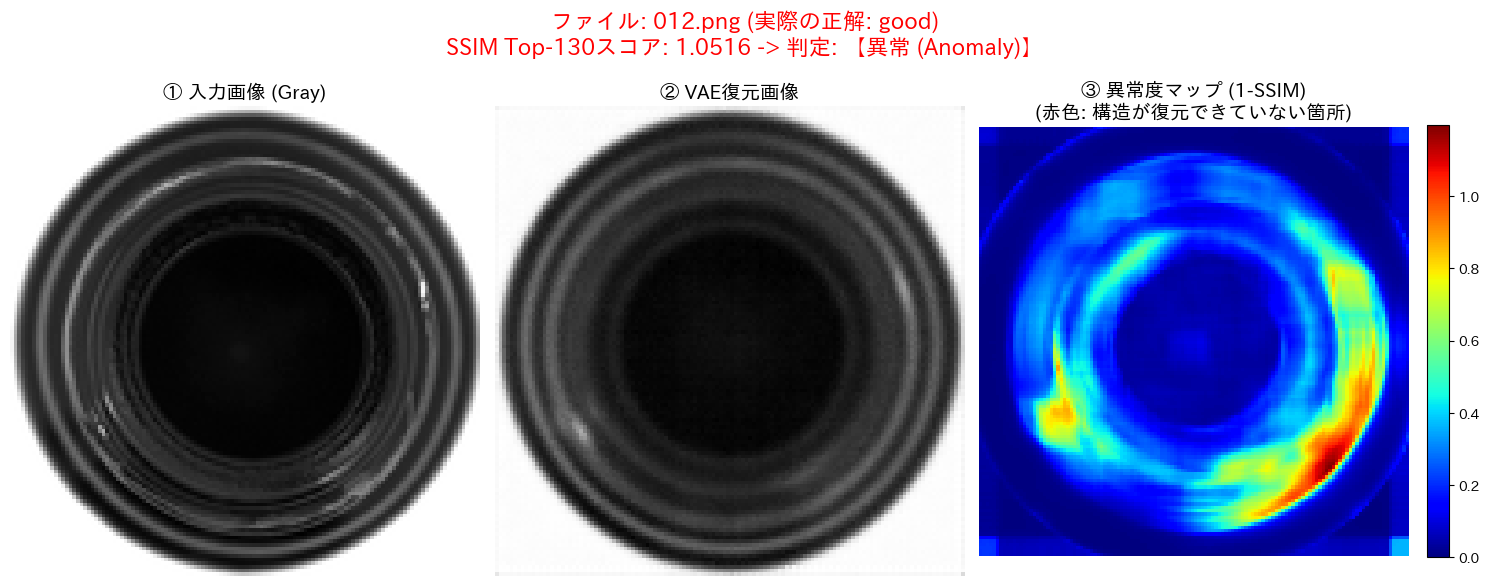


【3. FN: 異常を「正常」と誤って判断 (見逃し)】 : 該当 5 件中 2 件を表示


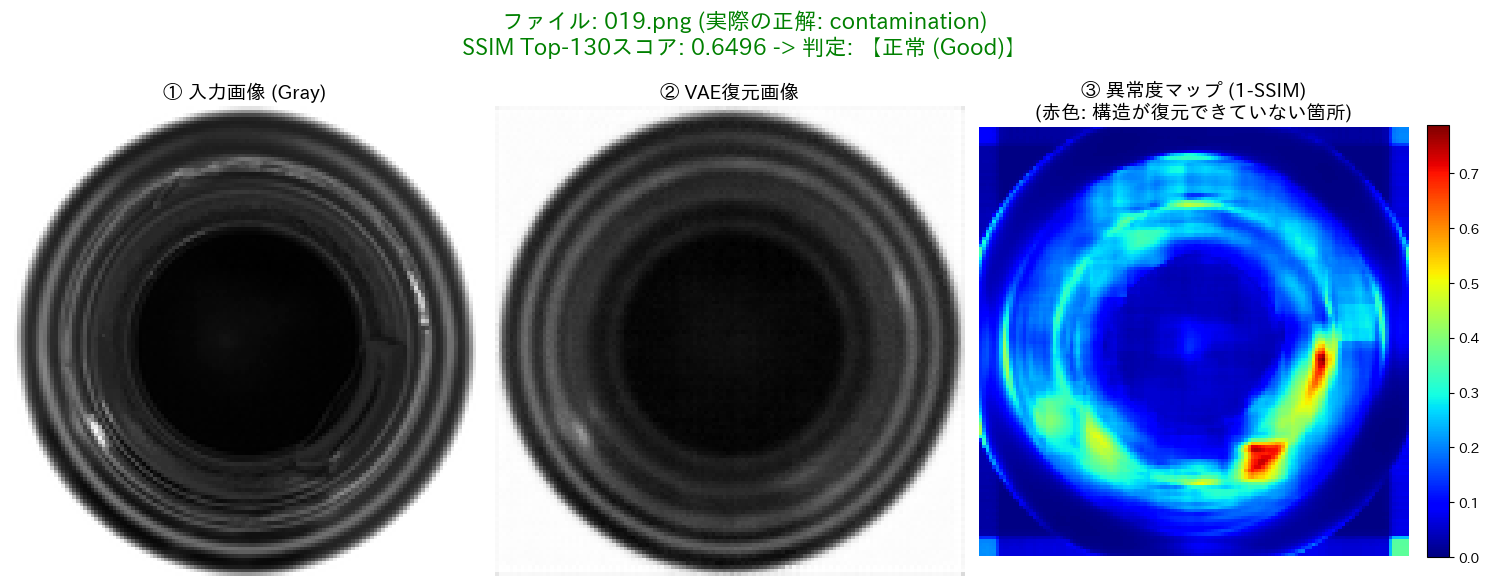

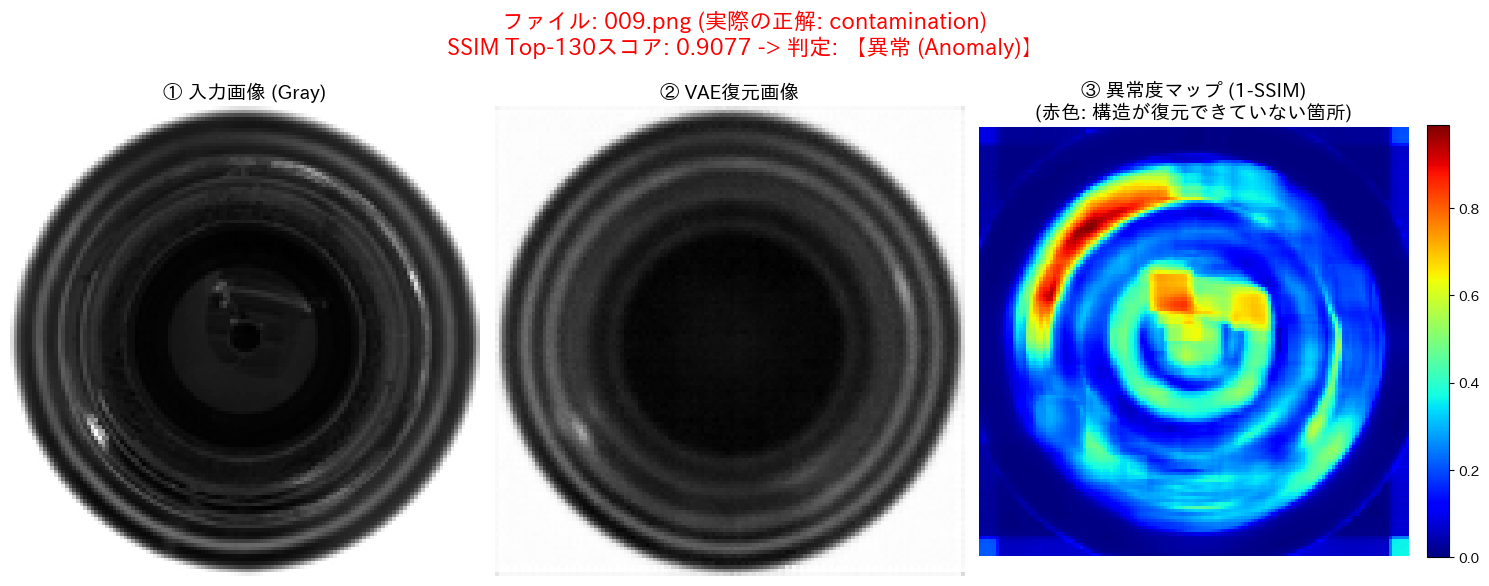


【4. TP: 異常を「異常」と正しく判断】 : 該当 58 件中 2 件を表示


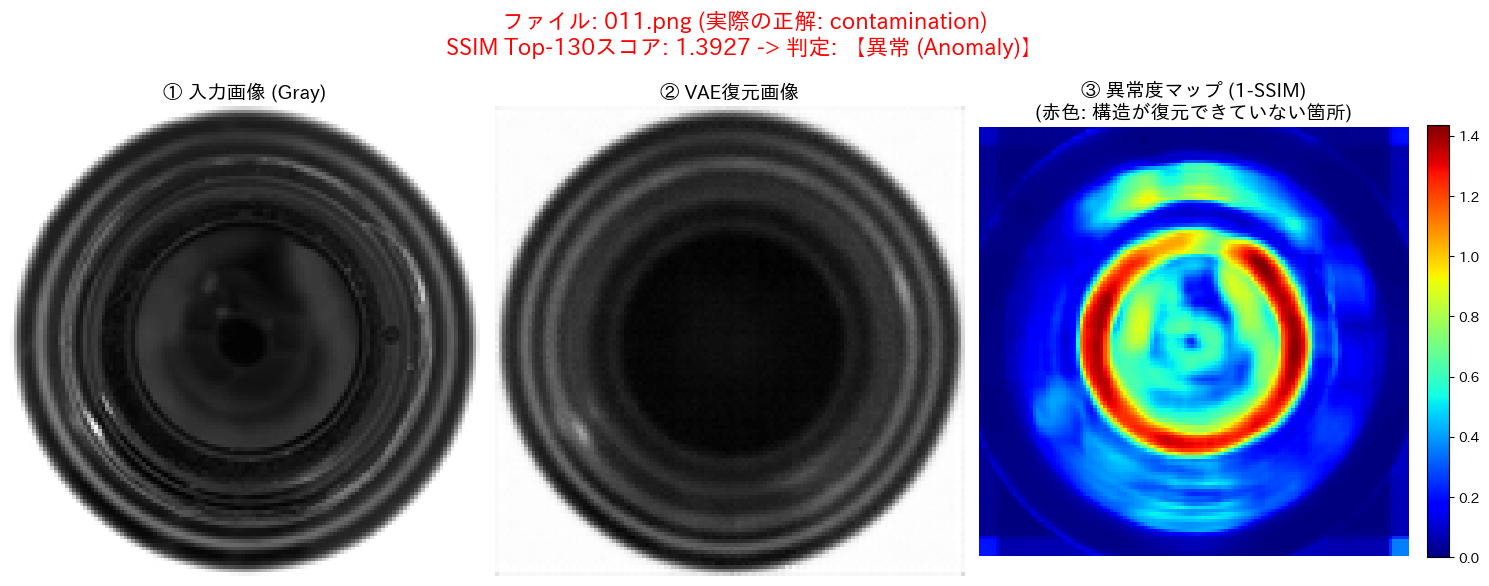

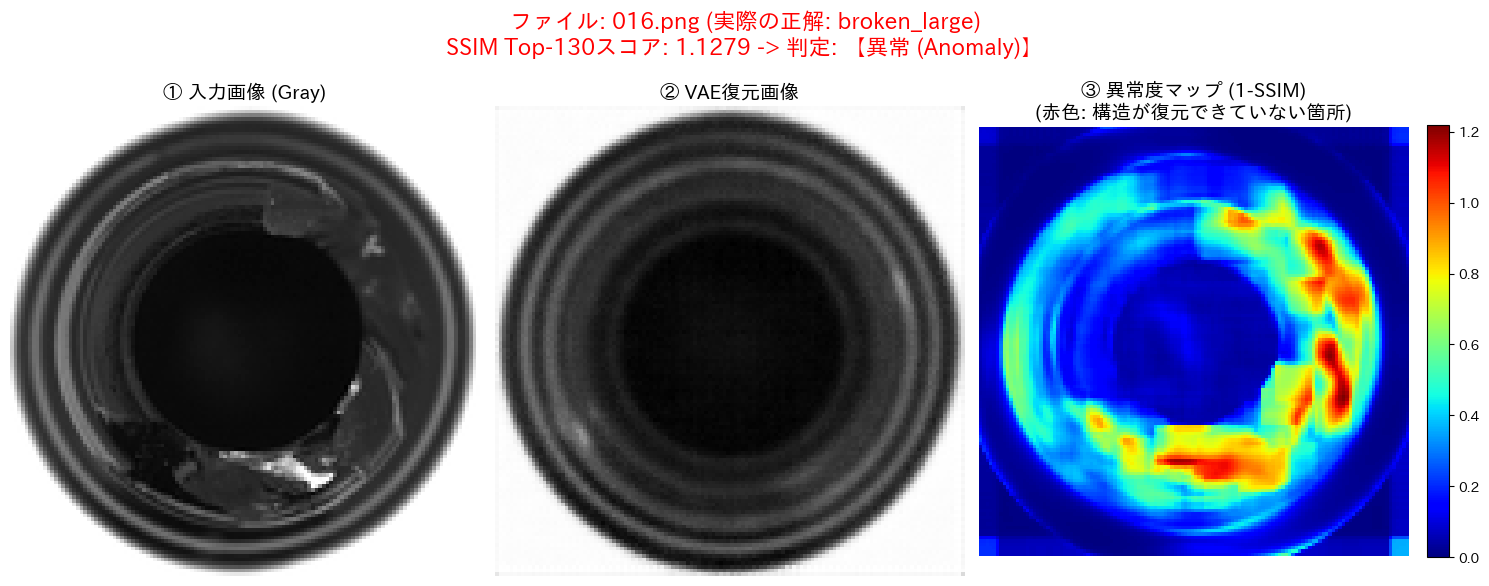


すべての検証プロセスが完了しました。


In [ ]:
# =====================================================================
# 検証用コード: ハイブリッドモデル（Hybrid_CNN5_FC）100epアニーリング版 専用
# 異常スコア: SSIM Top-K (上位130パッチの平均誤差)
# 閾値設定: 教師なし (パーセンタイル法)
# =====================================================================
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score
import random
from skimage.metrics import structural_similarity as ssim

# 文字化け対策の強制適用
import japanize_matplotlib
japanize_matplotlib.japanize()

# =====================================================================
# 1. 前処理とモデルの定義 (Hybrid_CNN5_FC版)
# =====================================================================
transform = transforms.Compose([
    transforms.CenterCrop(820),
    transforms.Resize((128, 128), interpolation=transforms.InterpolationMode.LANCZOS),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
])

class VAE_Hybrid_CNN_FC(nn.Module):
    def __init__(self, latent_dim=64):
        super(VAE_Hybrid_CNN_FC, self).__init__()
        
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(16), nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256), nn.ReLU()
        )
        
        self.encoder_fc = nn.Sequential(
            nn.Linear(256 * 4 * 4, 1024), nn.ReLU(),
            nn.Linear(1024, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU()
        )
        
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)
        
        self.decoder_fc = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, 1024), nn.ReLU(),
            nn.Linear(1024, 256 * 4 * 4), nn.ReLU()
        )
        
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(16), nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        h = self.encoder_conv(x)
        h = torch.flatten(h, start_dim=1)
        h = self.encoder_fc(h)
        
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        logvar = torch.clamp(logvar, min=-10.0, max=10.0)
        
        std = torch.exp(0.5 * logvar)
        z = mu + torch.randn_like(std) * std
        
        h_recon = self.decoder_fc(z)
        h_recon = h_recon.view(-1, 256, 4, 4) 
        recon = self.decoder_conv(h_recon)
        
        return recon, mu, logvar

# =====================================================================
# 2. 評価と可視化の関数群
# =====================================================================
def evaluate_dataset(model, test_dir, device, top_k=130):
    model.eval()
    y_true, scores, all_image_paths = [], [], [] 
    
    test_dir = Path(test_dir)
    if not test_dir.exists():
        raise FileNotFoundError(f"テストディレクトリが見つかりません: {test_dir}\n研究室PCのデータパスを確認してください。")

    print(f"テストデータ全件の評価を開始します... (モデル: Hybrid_CNN5_FC, Top-K: {top_k})")
    
    with torch.no_grad():
        for folder in test_dir.iterdir():
            if not folder.is_dir():
                continue
                
            true_label = 0 if folder.name == "good" else 1
            img_paths = list(folder.glob("*.png"))
            if not img_paths:
                continue

            for img_path in img_paths:
                img = Image.open(img_path).convert('RGB')
                input_tensor = transform(img).unsqueeze(0).to(device)

                recon_tensor, _, _ = model(input_tensor)
                input_img = input_tensor.squeeze().cpu().numpy()
                recon_img = recon_tensor.squeeze().cpu().numpy()

                _, ssim_map = ssim(input_img, recon_img, data_range=1.0, win_size=11, full=True)
                anomaly_map = 1.0 - ssim_map

                sorted_anomaly = np.sort(anomaly_map.flatten())[::-1]
                top_k_score = np.mean(sorted_anomaly[:top_k])

                y_true.append(true_label)
                scores.append(top_k_score)
                all_image_paths.append(img_path)

    print("評価が完了しました。")
    return np.array(y_true), np.array(scores), all_image_paths

def plot_confusion_matrix(y_true, y_pred, threshold, top_k=130):
    acc = accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"\n--- 定量評価結果 (Hybrid_CNN5_FC) ---")
    print(f"設定閾値: {threshold:.4f}")
    print(f"正解率 (Accuracy)  : {acc * 100:.2f}%")
    print(f"適合率 (Precision) : {precision * 100:.2f}%")
    print(f"再現率 (Recall)    : {recall * 100:.2f}%")
    print(f"F値 (F1-score)     : {f1 * 100:.2f}%\n")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['正常予測', '異常予測'],
                yticklabels=['実際の正常', '実際の異常'],
                annot_kws={"size": 16})

    title_str = (f"混同行列 (Hybrid_CNN5_FC | SSIM Top-{top_k})\n"
                 f"Acc: {acc*100:.1f}% | Precision: {precision*100:.1f}%\n"
                 f"Recall: {recall*100:.1f}% | F1: {f1*100:.1f}%")
    
    plt.title(title_str, fontsize=14)
    plt.xlabel('AIの予測', fontsize=14)
    plt.ylabel('実際の正解', fontsize=14)
    plt.tight_layout()
    plt.show()

def plot_score_distribution(y_true, scores, threshold, top_k=130):
    plt.figure(figsize=(10, 6))

    normal_scores = scores[y_true == 0]
    anomaly_scores = scores[y_true == 1]

    min_score = np.min(scores)
    max_score = np.max(scores)
    common_bins = np.linspace(min_score, max_score, 40)

    sns.histplot(normal_scores, bins=common_bins, color='green', alpha=0.5, label='正常 (Good)', kde=False)
    sns.histplot(anomaly_scores, bins=common_bins, color='red', alpha=0.5, label='異常 (Anomaly)', kde=False)

    plt.axvline(x=threshold, color='blue', linestyle='--', linewidth=2, label=f'現在の閾値 ({threshold:.4f})')

    plt.title(f"異常スコアの分布 (Hybrid_CNN5_FC | SSIM Top-{top_k})", fontsize=16, fontweight='bold')# =====================================================================
# 検証用コード: ハイブリッドモデル（Hybrid_CNN5_FC）100epアニーリング版 専用
# 異常スコア: SSIM Top-K (上位130パッチの平均誤差)
# 閾値設定: 教師なし (パーセンタイル法)
# =====================================================================
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score
import random
from skimage.metrics import structural_similarity as ssim

# 文字化け対策の強制適用
import japanize_matplotlib
japanize_matplotlib.japanize()

# =====================================================================
# 1. 前処理とモデルの定義 (Hybrid_CNN5_FC版)
# =====================================================================
transform = transforms.Compose([
    transforms.CenterCrop(820),
    transforms.Resize((128, 128), interpolation=transforms.InterpolationMode.LANCZOS),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
])

class VAE_Hybrid_CNN_FC(nn.Module):
    def __init__(self, latent_dim=64):
        super(VAE_Hybrid_CNN_FC, self).__init__()
        
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(16), nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256), nn.ReLU()
        )
        
        self.encoder_fc = nn.Sequential(
            nn.Linear(256 * 4 * 4, 1024), nn.ReLU(),
            nn.Linear(1024, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU()
        )
        
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)
        
        self.decoder_fc = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, 1024), nn.ReLU(),
            nn.Linear(1024, 256 * 4 * 4), nn.ReLU()
        )
        
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(16), nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        h = self.encoder_conv(x)
        h = torch.flatten(h, start_dim=1)
        h = self.encoder_fc(h)
        
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        logvar = torch.clamp(logvar, min=-10.0, max=10.0)
        
        std = torch.exp(0.5 * logvar)
        z = mu + torch.randn_like(std) * std
        
        h_recon = self.decoder_fc(z)
        h_recon = h_recon.view(-1, 256, 4, 4) 
        recon = self.decoder_conv(h_recon)
        
        return recon, mu, logvar

# =====================================================================
# 2. 評価と可視化の関数群
# =====================================================================
def evaluate_dataset(model, test_dir, device, top_k=130):
    model.eval()
    y_true, scores, all_image_paths = [], [], [] 
    
    test_dir = Path(test_dir)
    if not test_dir.exists():
        raise FileNotFoundError(f"テストディレクトリが見つかりません: {test_dir}\n研究室PCのデータパスを確認してください。")

    print(f"テストデータ全件の評価を開始します... (モデル: Hybrid_CNN5_FC, Top-K: {top_k})")
    
    with torch.no_grad():
        for folder in test_dir.iterdir():
            if not folder.is_dir():
                continue
                
            true_label = 0 if folder.name == "good" else 1
            img_paths = list(folder.glob("*.png"))
            if not img_paths:
                continue

            for img_path in img_paths:
                img = Image.open(img_path).convert('RGB')
                input_tensor = transform(img).unsqueeze(0).to(device)

                recon_tensor, _, _ = model(input_tensor)
                input_img = input_tensor.squeeze().cpu().numpy()
                recon_img = recon_tensor.squeeze().cpu().numpy()

                _, ssim_map = ssim(input_img, recon_img, data_range=1.0, win_size=11, full=True)
                anomaly_map = 1.0 - ssim_map

                sorted_anomaly = np.sort(anomaly_map.flatten())[::-1]
                top_k_score = np.mean(sorted_anomaly[:top_k])

                y_true.append(true_label)
                scores.append(top_k_score)
                all_image_paths.append(img_path)

    print("評価が完了しました。")
    return np.array(y_true), np.array(scores), all_image_paths

def plot_confusion_matrix(y_true, y_pred, threshold, top_k=130):
    acc = accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"\n--- 定量評価結果 (Hybrid_CNN5_FC) ---")
    print(f"設定閾値: {threshold:.4f}")
    print(f"正解率 (Accuracy)  : {acc * 100:.2f}%")
    print(f"適合率 (Precision) : {precision * 100:.2f}%")
    print(f"再現率 (Recall)    : {recall * 100:.2f}%")
    print(f"F値 (F1-score)     : {f1 * 100:.2f}%\n")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['正常予測', '異常予測'],
                yticklabels=['実際の正常', '実際の異常'],
                annot_kws={"size": 16})

    title_str = (f"混同行列 (Hybrid_CNN5_FC | SSIM Top-{top_k})\n"
                 f"Acc: {acc*100:.1f}% | Precision: {precision*100:.1f}%\n"
                 f"Recall: {recall*100:.1f}% | F1: {f1*100:.1f}%")
    
    plt.title(title_str, fontsize=14)
    plt.xlabel('AIの予測', fontsize=14)
    plt.ylabel('実際の正解', fontsize=14)
    plt.tight_layout()
    plt.show()

def plot_score_distribution(y_true, scores, threshold, top_k=130):
    plt.figure(figsize=(10, 6))

    normal_scores = scores[y_true == 0]
    anomaly_scores = scores[y_true == 1]

    min_score = np.min(scores)
    max_score = np.max(scores)
    common_bins = np.linspace(min_score, max_score, 40)

    sns.histplot(normal_scores, bins=common_bins, color='green', alpha=0.5, label='正常 (Good)', kde=False)
    sns.histplot(anomaly_scores, bins=common_bins, color='red', alpha=0.5, label='異常 (Anomaly)', kde=False)

    plt.axvline(x=threshold, color='blue', linestyle='--', linewidth=2, label=f'現在の閾値 ({threshold:.4f})')

    plt.title(f"異常スコアの分布 (Hybrid_CNN5_FC | SSIM Top-{top_k})", fontsize=16, fontweight='bold')
    plt.xlabel(f"異常スコア (上位{top_k}パッチの類似度誤差平均)", fontsize=14)
    plt.ylabel("画像の数 (Count)", fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# 【新規追加】正常データのみの分布と閾値を可視化する最強の図解
import matplotlib.ticker as ticker # ファイル上部のimport群に追加してもOKです

def plot_unsupervised_threshold(y_true, scores, threshold, percentile=95.0):
    plt.figure(figsize=(10, 6))

    # 正常データのスコアのみを抽出
    normal_scores = scores[y_true == 0]

    # ヒストグラムの描画
    sns.histplot(normal_scores, bins=30, color='mediumseagreen', alpha=0.7,  label='正常データ (Good)')

    # ★ Y軸を1枚刻み（整数）に強制する設定
    plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    # 閾値の垂直線
    plt.axvline(x=threshold, color='red', linestyle='--', linewidth=2.5, label=f'設定閾値 ({percentile}パーセンタイル)')

    # グラフのX軸の描画範囲を取得し、閾値より右側（上位数%）を赤くハイライト
    x_min, x_max = plt.xlim()
    plt.axvspan(threshold, x_max, color='red', alpha=0.15, label=f'上位 {100-percentile:.1f}% (過剰検知として許容)')
    plt.xlim(x_min, x_max) # 描画範囲を維持

    plt.title(f"教師なし閾値設定のメカニズム (正常データの上位 {100-percentile:.1f}% を閾値とする)", fontsize=16, fontweight='bold')
    plt.xlabel("異常スコア (正常データのみ)", fontsize=14)
    plt.ylabel("画像の数 (Count)", fontsize=14)
    plt.legend(fontsize=12, loc='upper right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

def plot_single_anomaly(model, image_path, device, threshold, top_k=130):
    model.eval()
    img = Image.open(image_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        recon_tensor, _, _ = model(input_tensor)

    input_img = input_tensor.squeeze().cpu().numpy()
    recon_img = recon_tensor.squeeze().cpu().numpy()

    _, ssim_map = ssim(input_img, recon_img, data_range=1.0, win_size=11, full=True)
    anomaly_map = 1.0 - ssim_map
    sorted_anomaly = np.sort(anomaly_map.flatten())[::-1]
    top_k_score = np.mean(sorted_anomaly[:top_k])

    is_anomaly = top_k_score > threshold
    judgment = "【異常 (Anomaly)】" if is_anomaly else "【正常 (Good)】"
    result_color = 'red' if is_anomaly else 'green'

    fig, axes = plt.subplots(1, 3, figsize=(15, 6))
    fig.suptitle(f"ファイル: {image_path.name} (実際の正解: {image_path.parent.name})\nSSIM Top-{top_k}スコア: {top_k_score:.4f} -> 判定: {judgment}",
                 fontsize=16, fontweight='bold', color=result_color)

    axes[0].imshow(input_img, cmap='gray')
    axes[0].set_title("① 入力画像 (Gray)", fontsize=14)
    axes[0].axis('off')

    axes[1].imshow(recon_img, cmap='gray')
    axes[1].set_title("② VAE復元画像", fontsize=14)
    axes[1].axis('off')

    vmax_val = np.max(anomaly_map) if np.max(anomaly_map) > 0.1 else 0.1
    im3 = axes[2].imshow(anomaly_map, cmap='jet', vmin=0, vmax=vmax_val)
    axes[2].set_title(f"③ 異常度マップ (1-SSIM)\n(赤色: 構造が復元できていない箇所)", fontsize=14)
    axes[2].axis('off')
    fig.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

def compute_unsupervised_threshold(y_true, scores, method="percentile", k=3.0, percentile=95.0):
    normal_scores = scores[y_true == 0]
    
    if method == "sigma":
        mu = np.mean(normal_scores)
        sigma = np.std(normal_scores)
        threshold = mu + k * sigma
        print(f"\n[教師なししきい値設定: {k}σ法]")
        print(f"-> 正常データの平均(μ): {mu:.4f}, 標準偏差(σ): {sigma:.4f}")
        print(f"-> 最適しきい値: {threshold:.4f}")
        
    elif method == "percentile":
        threshold = np.percentile(normal_scores, percentile, method='lower')
        print(f"\n[教師なししきい値設定: パーセンタイル法 ({percentile}%)]")
        print(f"-> 正常データの {percentile}% を正常とみなす")
        print(f"-> 最適しきい値: {threshold:.4f}")
        
    return threshold

# =====================================================================
# 3. 実行ブロック
# =====================================================================
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"使用デバイス: {device}")

    model = VAE_Hybrid_CNN_FC(latent_dim=64).to(device)
    MODEL_PATH = "/home/okoshi/my_GItHub/image-anomaly-detection/saved_models/vae_Hybrid_CNN5_FC_Annealing_ep100_beta50_128.pth"

    if not Path(MODEL_PATH).exists():
        raise FileNotFoundError(f"重みファイルが見つかりません: {MODEL_PATH}\n学習が完了しているか、パスが正しいか確認してください。")

    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    print(f"Hybrid_CNN5_FC の重みを読み込みました。\n")

    TEST_DIR = "/home/okoshi/my_GItHub/image-anomaly-detection/data/bottle/test"
    TOP_K = 130
    PERCENTILE_VAL = 95.0 

    # 1. まず全画像の異常スコアを算出
    y_true, scores, all_image_paths = evaluate_dataset(model, TEST_DIR, device, top_k=TOP_K)

    # 2. 正常データのみの分布（パーセンタイル法）で閾値を自動計算
    THRESHOLD = compute_unsupervised_threshold(y_true, scores, method="percentile", percentile=PERCENTILE_VAL)

    # 3. 決定したしきい値を用いて予測ラベルを作成
    y_pred = (scores > THRESHOLD).astype(int)

    # 4. グラフの描画
    plot_confusion_matrix(y_true, y_pred, THRESHOLD, top_k=TOP_K)
    plot_score_distribution(y_true, scores, THRESHOLD, top_k=TOP_K)

    # 【追加】正常データのみの分布と閾値位置の可視化
    plot_unsupervised_threshold(y_true, scores, THRESHOLD, percentile=PERCENTILE_VAL)

    print("\n--- パターン別の代表例を可視化します ---")
    tn_paths, fp_paths, fn_paths, tp_paths = [], [], [], []
    for true_lbl, pred_lbl, path in zip(y_true, y_pred, all_image_paths):
        if true_lbl == 0 and pred_lbl == 0: tn_paths.append(path)
        elif true_lbl == 0 and pred_lbl == 1: fp_paths.append(path)
        elif true_lbl == 1 and pred_lbl == 0: fn_paths.append(path)
        elif true_lbl == 1 and pred_lbl == 1: tp_paths.append(path)

    categories = {
        "【1. TN: 正常を「正常」と正しく判断】": tn_paths,
        "【2. FP: 正常を「異常」と誤って判断 (過剰検知)】": fp_paths,
        "【3. FN: 異常を「正常」と誤って判断 (見逃し)】": fn_paths,
        "【4. TP: 異常を「異常」と正しく判断】": tp_paths
    }

    for title, paths in categories.items():
        sample_size = min(2, len(paths))
        print(f"\n{title} : 該当 {len(paths)} 件中 {sample_size} 件を表示")

        if sample_size > 0:
            sampled_paths = random.sample(paths, sample_size)
            for img_path in sampled_paths:
                plot_single_anomaly(model, img_path, device, THRESHOLD, top_k=TOP_K)
        else:
            print("  -> このパターンに該当する画像はありません。")

    print("\nすべての検証プロセスが完了しました。")
    plt.xlabel(f"異常スコア (上位{top_k}パッチの類似度誤差平均)", fontsize=14)
    plt.ylabel("画像の数 (Count)", fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# 【新規追加】正常データのみの分布と閾値を可視化する最強の図解
import matplotlib.ticker as ticker # ファイル上部のimport群に追加してもOKです

def plot_unsupervised_threshold(y_true, scores, threshold, percentile=95.0):
    plt.figure(figsize=(10, 6))

    # 正常データのスコアのみを抽出
    normal_scores = scores[y_true == 0]

    # ヒストグラムの描画
    sns.histplot(normal_scores, bins=30, color='mediumseagreen', alpha=0.7,  label='正常データ (Good)')

    # ★ Y軸を1枚刻み（整数）に強制する設定
    plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    # 閾値の垂直線
    plt.axvline(x=threshold, color='red', linestyle='--', linewidth=2.5, label=f'設定閾値 ({percentile}パーセンタイル)')

    # グラフのX軸の描画範囲を取得し、閾値より右側（上位数%）を赤くハイライト
    x_min, x_max = plt.xlim()
    plt.axvspan(threshold, x_max, color='red', alpha=0.15, label=f'上位 {100-percentile:.1f}% (過剰検知として許容)')
    plt.xlim(x_min, x_max) # 描画範囲を維持

    plt.title(f"教師なし閾値設定のメカニズム (正常データの上位 {100-percentile:.1f}% を閾値とする)", fontsize=16, fontweight='bold')
    plt.xlabel("異常スコア (正常データのみ)", fontsize=14)
    plt.ylabel("画像の数 (Count)", fontsize=14)
    plt.legend(fontsize=12, loc='upper right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

def plot_single_anomaly(model, image_path, device, threshold, top_k=130):
    model.eval()
    img = Image.open(image_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        recon_tensor, _, _ = model(input_tensor)

    input_img = input_tensor.squeeze().cpu().numpy()
    recon_img = recon_tensor.squeeze().cpu().numpy()

    _, ssim_map = ssim(input_img, recon_img, data_range=1.0, win_size=11, full=True)
    anomaly_map = 1.0 - ssim_map
    sorted_anomaly = np.sort(anomaly_map.flatten())[::-1]
    top_k_score = np.mean(sorted_anomaly[:top_k])

    is_anomaly = top_k_score > threshold
    judgment = "【異常 (Anomaly)】" if is_anomaly else "【正常 (Good)】"
    result_color = 'red' if is_anomaly else 'green'

    fig, axes = plt.subplots(1, 3, figsize=(15, 6))
    fig.suptitle(f"ファイル: {image_path.name} (実際の正解: {image_path.parent.name})\nSSIM Top-{top_k}スコア: {top_k_score:.4f} -> 判定: {judgment}",
                 fontsize=16, fontweight='bold', color=result_color)

    axes[0].imshow(input_img, cmap='gray')
    axes[0].set_title("① 入力画像 (Gray)", fontsize=14)
    axes[0].axis('off')

    axes[1].imshow(recon_img, cmap='gray')
    axes[1].set_title("② VAE復元画像", fontsize=14)
    axes[1].axis('off')

    vmax_val = np.max(anomaly_map) if np.max(anomaly_map) > 0.1 else 0.1
    im3 = axes[2].imshow(anomaly_map, cmap='jet', vmin=0, vmax=vmax_val)
    axes[2].set_title(f"③ 異常度マップ (1-SSIM)\n(赤色: 構造が復元できていない箇所)", fontsize=14)
    axes[2].axis('off')
    fig.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

def compute_unsupervised_threshold(y_true, scores, method="percentile", k=3.0, percentile=95.0):
    normal_scores = scores[y_true == 0]
    
    if method == "sigma":
        mu = np.mean(normal_scores)
        sigma = np.std(normal_scores)
        threshold = mu + k * sigma
        print(f"\n[教師なししきい値設定: {k}σ法]")
        print(f"-> 正常データの平均(μ): {mu:.4f}, 標準偏差(σ): {sigma:.4f}")
        print(f"-> 最適しきい値: {threshold:.4f}")
        
    elif method == "percentile":
        threshold = np.percentile(normal_scores, percentile, method='lower')
        print(f"\n[教師なししきい値設定: パーセンタイル法 ({percentile}%)]")
        print(f"-> 正常データの {percentile}% を正常とみなす")
        print(f"-> 最適しきい値: {threshold:.4f}")
        
    return threshold

# =====================================================================
# 3. 実行ブロック
# =====================================================================
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"使用デバイス: {device}")

    model = VAE_Hybrid_CNN_FC(latent_dim=64).to(device)
    MODEL_PATH = "/home/okoshi/my_GItHub/image-anomaly-detection/saved_models/vae_Hybrid_CNN5_FC_Annealing_ep100_beta50_128.pth"

    if not Path(MODEL_PATH).exists():
        raise FileNotFoundError(f"重みファイルが見つかりません: {MODEL_PATH}\n学習が完了しているか、パスが正しいか確認してください。")

    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    print(f"Hybrid_CNN5_FC の重みを読み込みました。\n")

    TEST_DIR = "/home/okoshi/my_GItHub/image-anomaly-detection/data/bottle/test"
    TOP_K = 130
    PERCENTILE_VAL = 95.0 

    # 1. まず全画像の異常スコアを算出
    y_true, scores, all_image_paths = evaluate_dataset(model, TEST_DIR, device, top_k=TOP_K)

    # 2. 正常データのみの分布（パーセンタイル法）で閾値を自動計算
    THRESHOLD = compute_unsupervised_threshold(y_true, scores, method="percentile", percentile=PERCENTILE_VAL)

    # 3. 決定したしきい値を用いて予測ラベルを作成
    y_pred = (scores > THRESHOLD).astype(int)

    # 4. グラフの描画
    plot_confusion_matrix(y_true, y_pred, THRESHOLD, top_k=TOP_K)
    plot_score_distribution(y_true, scores, THRESHOLD, top_k=TOP_K)

    # 【追加】正常データのみの分布と閾値位置の可視化
    plot_unsupervised_threshold(y_true, scores, THRESHOLD, percentile=PERCENTILE_VAL)

    print("\n--- パターン別の代表例を可視化します ---")
    tn_paths, fp_paths, fn_paths, tp_paths = [], [], [], []
    for true_lbl, pred_lbl, path in zip(y_true, y_pred, all_image_paths):
        if true_lbl == 0 and pred_lbl == 0: tn_paths.append(path)
        elif true_lbl == 0 and pred_lbl == 1: fp_paths.append(path)
        elif true_lbl == 1 and pred_lbl == 0: fn_paths.append(path)
        elif true_lbl == 1 and pred_lbl == 1: tp_paths.append(path)

    categories = {
        "【1. TN: 正常を「正常」と正しく判断】": tn_paths,
        "【2. FP: 正常を「異常」と誤って判断 (過剰検知)】": fp_paths,
        "【3. FN: 異常を「正常」と誤って判断 (見逃し)】": fn_paths,
        "【4. TP: 異常を「異常」と正しく判断】": tp_paths
    }

    for title, paths in categories.items():
        sample_size = min(2, len(paths))
        print(f"\n{title} : 該当 {len(paths)} 件中 {sample_size} 件を表示")

        if sample_size > 0:
            sampled_paths = random.sample(paths, sample_size)
            for img_path in sampled_paths:
                plot_single_anomaly(model, img_path, device, THRESHOLD, top_k=TOP_K)
        else:
            print("  -> このパターンに該当する画像はありません。")

    print("\nすべての検証プロセスが完了しました。")

使用デバイス: cuda
VAE_FC の重みを読み込みました。

テストデータ全件の評価を開始します... (モデル: VAE_FC, Top-K: 130)
評価が完了しました。

[教師なししきい値設定: パーセンタイル法 (95.0%)]
-> 正常データの 95.0% を正常とみなす
-> 最適しきい値: 0.8902

--- 定量評価結果 (VAE_FC) ---
設定閾値: 0.8902
正解率 (Accuracy)  : 93.98%
適合率 (Precision) : 98.33%
再現率 (Recall)    : 93.65%
F値 (F1-score)     : 95.93%



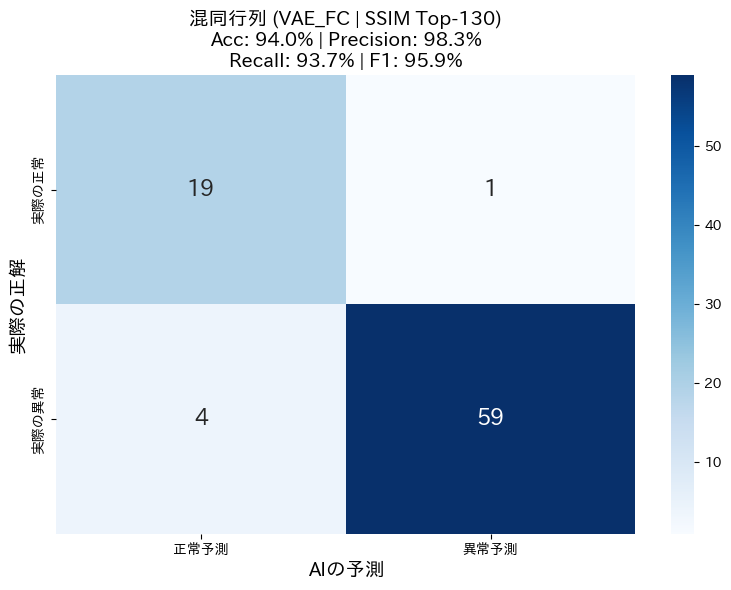

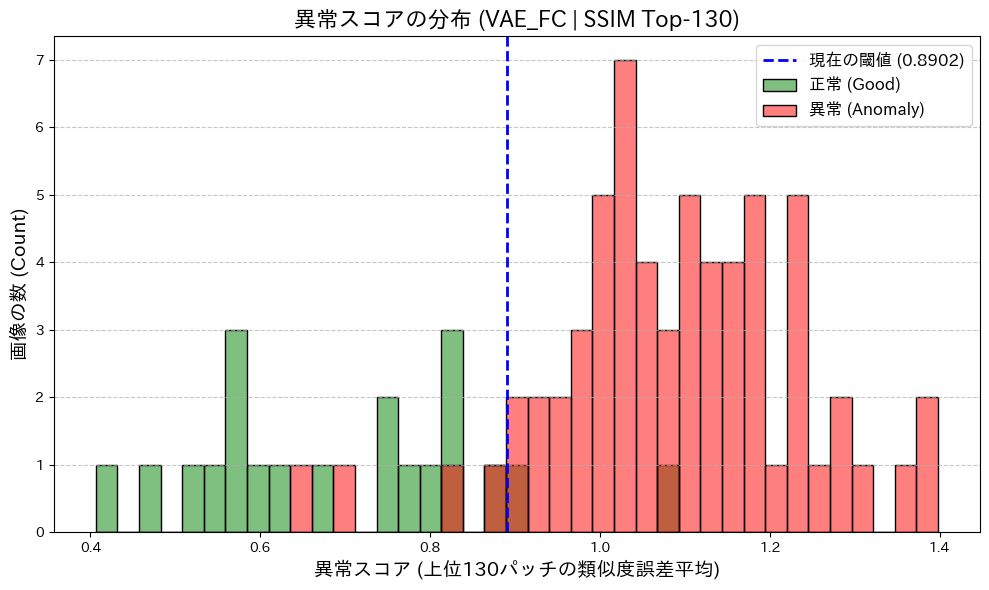

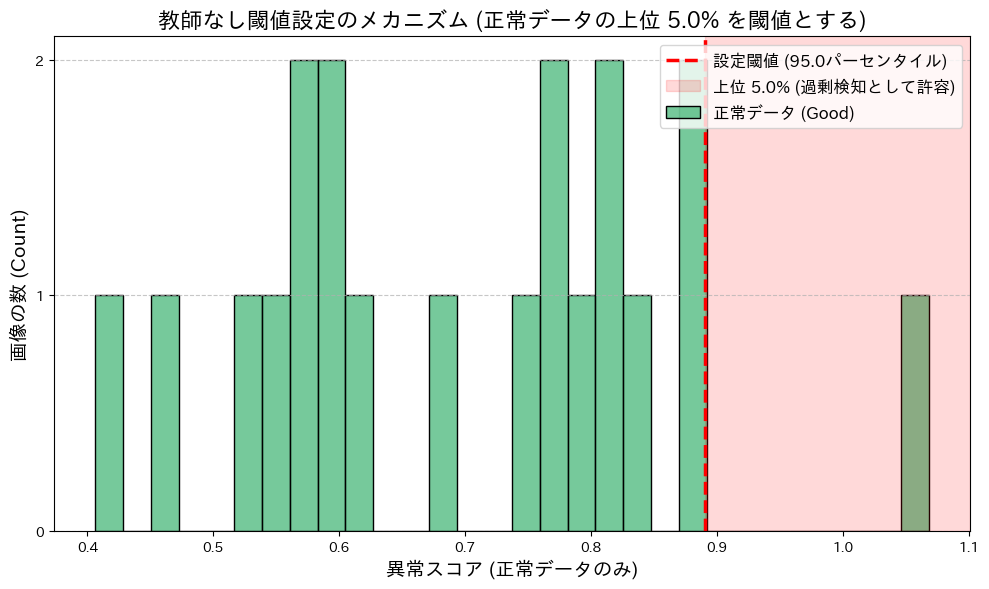


--- パターン別の代表例を可視化します ---

【1. TN: 正常を「正常」と正しく判断】 : 該当 19 件中 2 件を表示


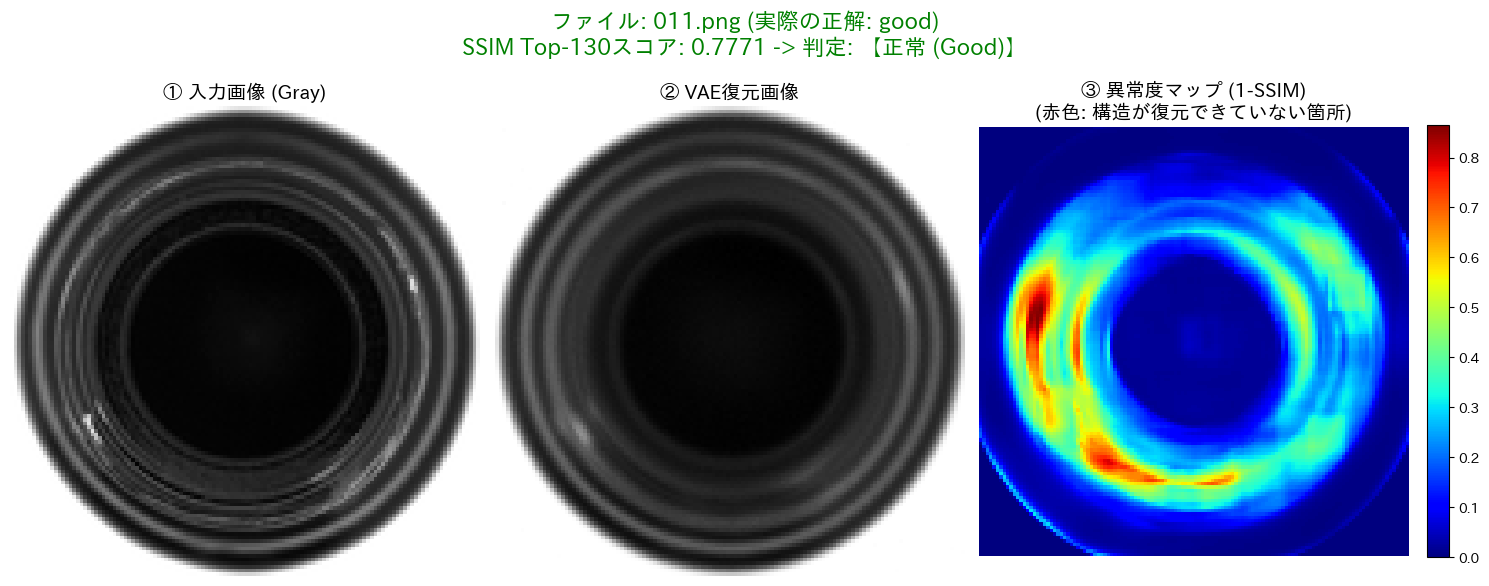

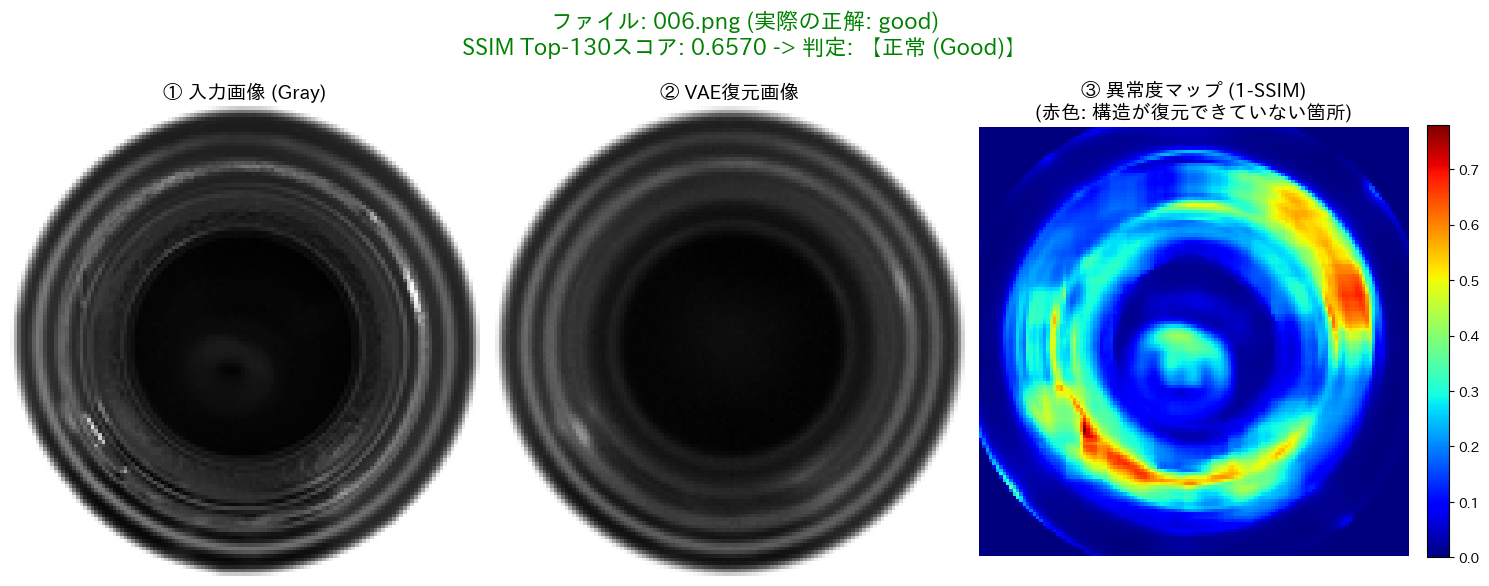


【2. FP: 正常を「異常」と誤って判断 (過剰検知)】 : 該当 1 件中 1 件を表示


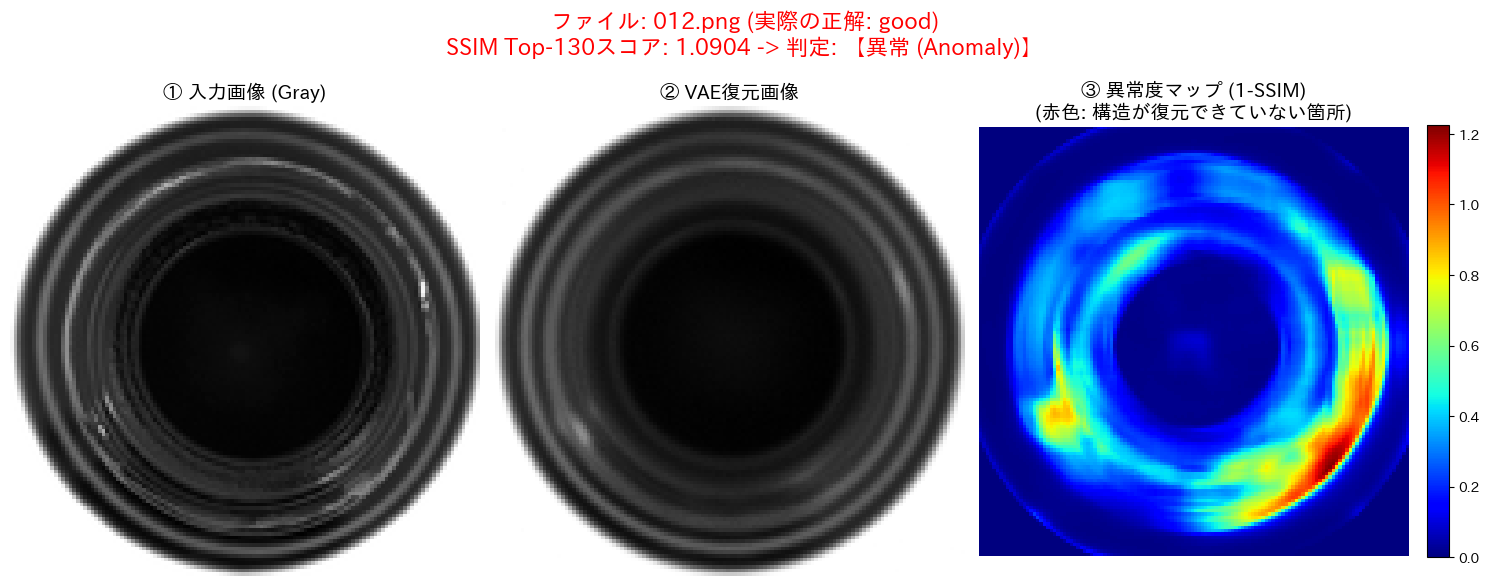


【3. FN: 異常を「正常」と誤って判断 (見逃し)】 : 該当 4 件中 2 件を表示


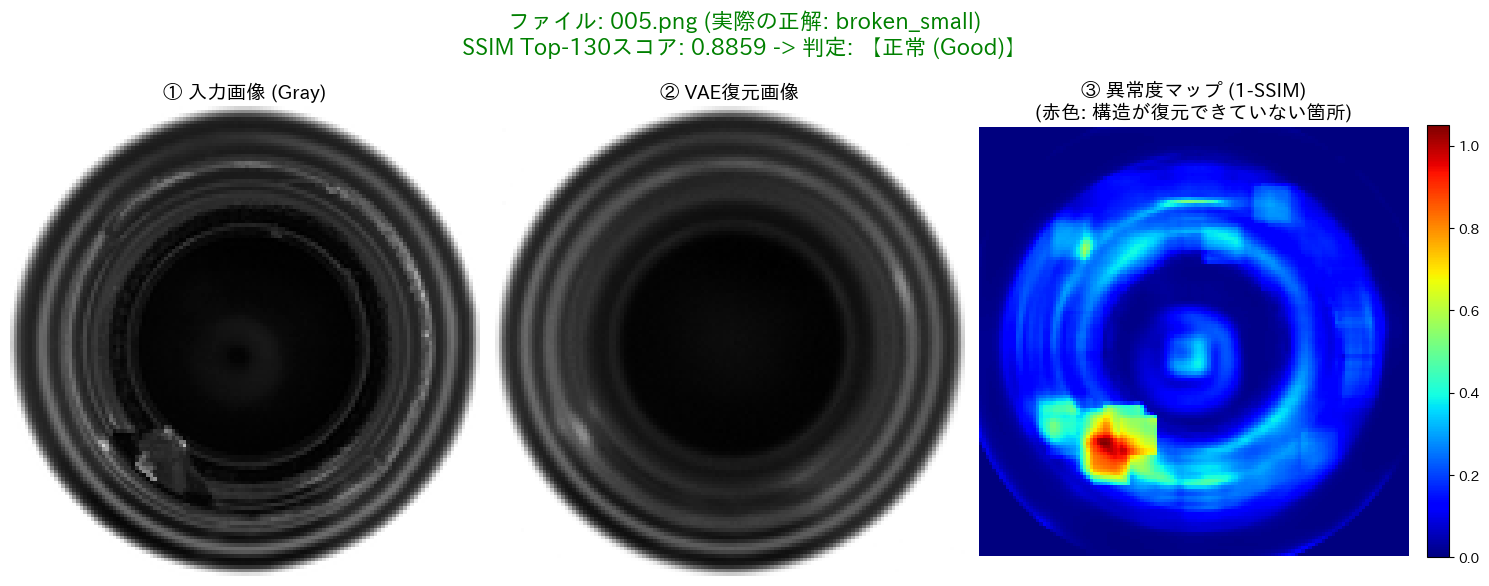

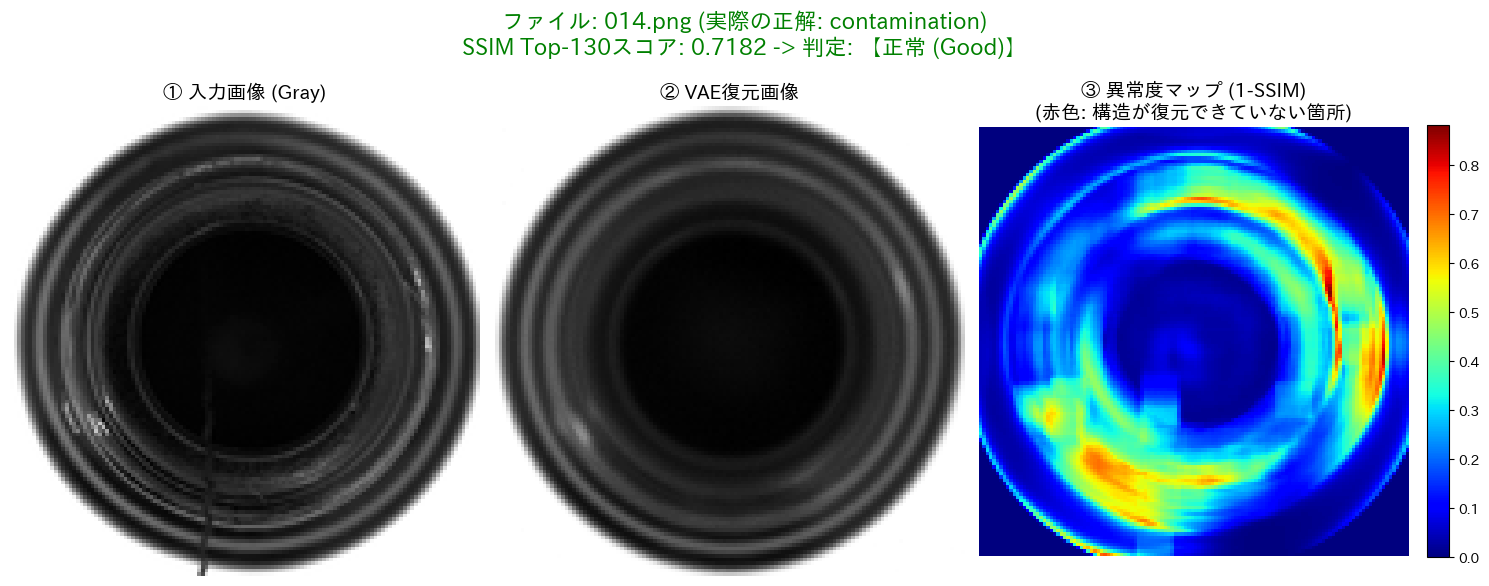


【4. TP: 異常を「異常」と正しく判断】 : 該当 59 件中 2 件を表示


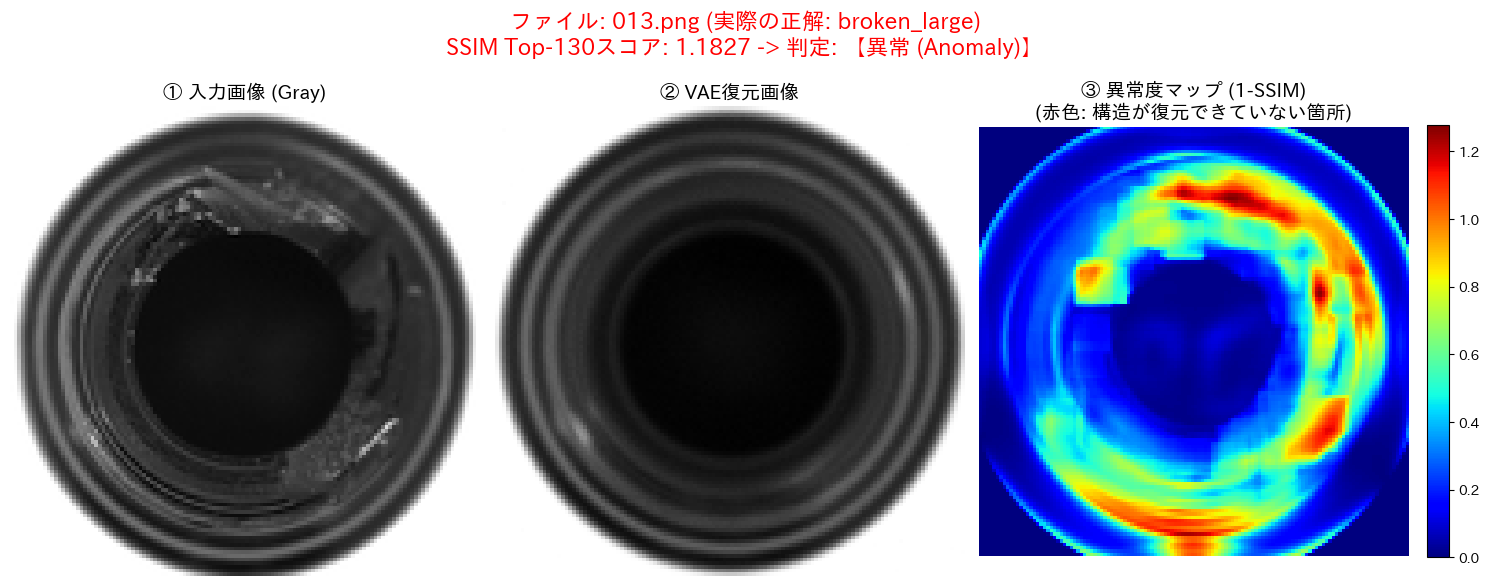

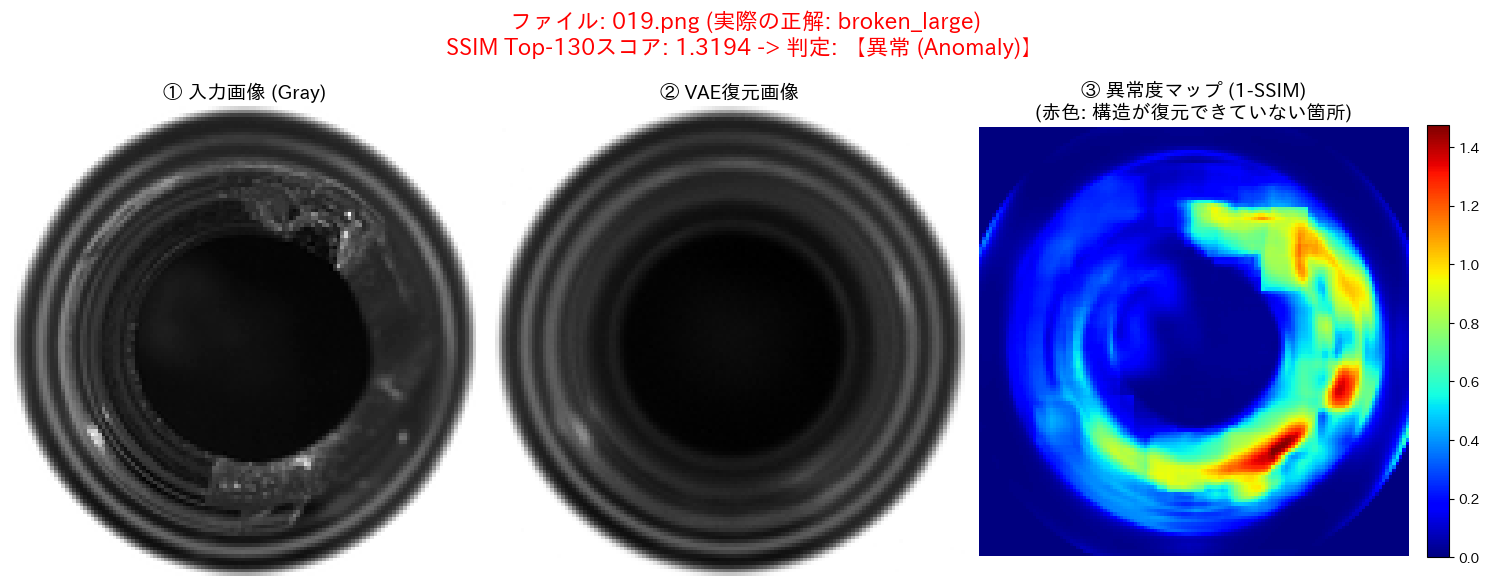


すべての検証プロセスが完了しました。


In [11]:
# =====================================================================
# 検証用コード: 全結合層モデル（VAE_FC） 専用
# 異常スコア: SSIM Top-K (上位130パッチの平均誤差)
# 閾値設定: 教師なし (パーセンタイル法)
# =====================================================================
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score
import random
from skimage.metrics import structural_similarity as ssim
import matplotlib.ticker as ticker

# 文字化け対策の強制適用
import japanize_matplotlib
japanize_matplotlib.japanize()

# =====================================================================
# 1. 前処理とモデルの定義 (VAE_FC版)
# =====================================================================
transform = transforms.Compose([
    transforms.CenterCrop(820),
    transforms.Resize((128, 128), interpolation=transforms.InterpolationMode.LANCZOS),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
])

# 評価対象のモデルクラス定義 (VAE_FC)
class VAE_FC(nn.Module):
    def __init__(self, latent_dim=64):
        super(VAE_FC, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(16384, 1024), nn.ReLU(),
            nn.Linear(1024, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU()
        )
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, 1024), nn.ReLU(),
            nn.Linear(1024, 16384), nn.Sigmoid()
        )

    def forward(self, x):
        h = torch.flatten(x, start_dim=1)
        h = self.encoder(h)
        mu, logvar = self.fc_mu(h), self.fc_logvar(h)
        std = torch.exp(0.5 * logvar)
        z = mu + torch.randn_like(std) * std
        recon = self.decoder(z)
        return recon.view(-1, 1, 128, 128), mu, logvar

# =====================================================================
# 2. 評価と可視化の関数群
# =====================================================================
def evaluate_dataset(model, test_dir, device, top_k=130):
    model.eval()
    y_true, scores, all_image_paths = [], [], [] 
    
    test_dir = Path(test_dir)
    if not test_dir.exists():
        raise FileNotFoundError(f"テストディレクトリが見つかりません: {test_dir}\nデータパスを確認してください。")

    print(f"テストデータ全件の評価を開始します... (モデル: VAE_FC, Top-K: {top_k})")
    
    with torch.no_grad():
        for folder in test_dir.iterdir():
            if not folder.is_dir():
                continue
                
            true_label = 0 if folder.name == "good" else 1
            img_paths = list(folder.glob("*.png"))
            if not img_paths:
                continue

            for img_path in img_paths:
                img = Image.open(img_path).convert('RGB')
                input_tensor = transform(img).unsqueeze(0).to(device)

                recon_tensor, _, _ = model(input_tensor)
                input_img = input_tensor.squeeze().cpu().numpy()
                recon_img = recon_tensor.squeeze().cpu().numpy()

                _, ssim_map = ssim(input_img, recon_img, data_range=1.0, win_size=11, full=True)
                anomaly_map = 1.0 - ssim_map

                sorted_anomaly = np.sort(anomaly_map.flatten())[::-1]
                top_k_score = np.mean(sorted_anomaly[:top_k])

                y_true.append(true_label)
                scores.append(top_k_score)
                all_image_paths.append(img_path)

    print("評価が完了しました。")
    return np.array(y_true), np.array(scores), all_image_paths

def plot_confusion_matrix(y_true, y_pred, threshold, top_k=130):
    acc = accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"\n--- 定量評価結果 (VAE_FC) ---")
    print(f"設定閾値: {threshold:.4f}")
    print(f"正解率 (Accuracy)  : {acc * 100:.2f}%")
    print(f"適合率 (Precision) : {precision * 100:.2f}%")
    print(f"再現率 (Recall)    : {recall * 100:.2f}%")
    print(f"F値 (F1-score)     : {f1 * 100:.2f}%\n")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['正常予測', '異常予測'],
                yticklabels=['実際の正常', '実際の異常'],
                annot_kws={"size": 16})

    title_str = (f"混同行列 (VAE_FC | SSIM Top-{top_k})\n"
                 f"Acc: {acc*100:.1f}% | Precision: {precision*100:.1f}%\n"
                 f"Recall: {recall*100:.1f}% | F1: {f1*100:.1f}%")
    
    plt.title(title_str, fontsize=14)
    plt.xlabel('AIの予測', fontsize=14)
    plt.ylabel('実際の正解', fontsize=14)
    plt.tight_layout()
    plt.show()

def plot_score_distribution(y_true, scores, threshold, top_k=130):
    plt.figure(figsize=(10, 6))

    normal_scores = scores[y_true == 0]
    anomaly_scores = scores[y_true == 1]

    min_score = np.min(scores)
    max_score = np.max(scores)
    common_bins = np.linspace(min_score, max_score, 40)

    sns.histplot(normal_scores, bins=common_bins, color='green', alpha=0.5, label='正常 (Good)', kde=False)
    sns.histplot(anomaly_scores, bins=common_bins, color='red', alpha=0.5, label='異常 (Anomaly)', kde=False)

    plt.axvline(x=threshold, color='blue', linestyle='--', linewidth=2, label=f'現在の閾値 ({threshold:.4f})')

    plt.title(f"異常スコアの分布 (VAE_FC | SSIM Top-{top_k})", fontsize=16, fontweight='bold')
    plt.xlabel(f"異常スコア (上位{top_k}パッチの類似度誤差平均)", fontsize=14)
    plt.ylabel("画像の数 (Count)", fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

def plot_unsupervised_threshold(y_true, scores, threshold, percentile=95.0):
    plt.figure(figsize=(10, 6))

    normal_scores = scores[y_true == 0]
    sns.histplot(normal_scores, bins=30, color='mediumseagreen', alpha=0.7,  label='正常データ (Good)')
    plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    plt.axvline(x=threshold, color='red', linestyle='--', linewidth=2.5, label=f'設定閾値 ({percentile}パーセンタイル)')

    x_min, x_max = plt.xlim()
    plt.axvspan(threshold, x_max, color='red', alpha=0.15, label=f'上位 {100-percentile:.1f}% (過剰検知として許容)')
    plt.xlim(x_min, x_max) 

    plt.title(f"教師なし閾値設定のメカニズム (正常データの上位 {100-percentile:.1f}% を閾値とする)", fontsize=16, fontweight='bold')
    plt.xlabel("異常スコア (正常データのみ)", fontsize=14)
    plt.ylabel("画像の数 (Count)", fontsize=14)
    plt.legend(fontsize=12, loc='upper right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

def plot_single_anomaly(model, image_path, device, threshold, top_k=130):
    model.eval()
    img = Image.open(image_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        recon_tensor, _, _ = model(input_tensor)

    input_img = input_tensor.squeeze().cpu().numpy()
    recon_img = recon_tensor.squeeze().cpu().numpy()

    _, ssim_map = ssim(input_img, recon_img, data_range=1.0, win_size=11, full=True)
    anomaly_map = 1.0 - ssim_map
    sorted_anomaly = np.sort(anomaly_map.flatten())[::-1]
    top_k_score = np.mean(sorted_anomaly[:top_k])

    is_anomaly = top_k_score > threshold
    judgment = "【異常 (Anomaly)】" if is_anomaly else "【正常 (Good)】"
    result_color = 'red' if is_anomaly else 'green'

    fig, axes = plt.subplots(1, 3, figsize=(15, 6))
    fig.suptitle(f"ファイル: {image_path.name} (実際の正解: {image_path.parent.name})\nSSIM Top-{top_k}スコア: {top_k_score:.4f} -> 判定: {judgment}",
                 fontsize=16, fontweight='bold', color=result_color)

    axes[0].imshow(input_img, cmap='gray')
    axes[0].set_title("① 入力画像 (Gray)", fontsize=14)
    axes[0].axis('off')

    axes[1].imshow(recon_img, cmap='gray')
    axes[1].set_title("② VAE復元画像", fontsize=14)
    axes[1].axis('off')

    vmax_val = np.max(anomaly_map) if np.max(anomaly_map) > 0.1 else 0.1
    im3 = axes[2].imshow(anomaly_map, cmap='jet', vmin=0, vmax=vmax_val)
    axes[2].set_title(f"③ 異常度マップ (1-SSIM)\n(赤色: 構造が復元できていない箇所)", fontsize=14)
    axes[2].axis('off')
    fig.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

def compute_unsupervised_threshold(y_true, scores, method="percentile", k=3.0, percentile=95.0):
    normal_scores = scores[y_true == 0]
    
    if method == "sigma":
        mu = np.mean(normal_scores)
        sigma = np.std(normal_scores)
        threshold = mu + k * sigma
        print(f"\n[教師なししきい値設定: {k}σ法]")
        print(f"-> 正常データの平均(μ): {mu:.4f}, 標準偏差(σ): {sigma:.4f}")
        print(f"-> 最適しきい値: {threshold:.4f}")
        
    elif method == "percentile":
        threshold = np.percentile(normal_scores, percentile, method='lower')
        print(f"\n[教師なししきい値設定: パーセンタイル法 ({percentile}%)]")
        print(f"-> 正常データの {percentile}% を正常とみなす")
        print(f"-> 最適しきい値: {threshold:.4f}")
        
    return threshold

# =====================================================================
# 3. 実行ブロック
# =====================================================================
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"使用デバイス: {device}")

    model = VAE_FC(latent_dim=64).to(device)
    
    # ★ ここを実際のFCモデルの重みファイル名に変更してください ★
    MODEL_PATH = "/home/okoshi/my_GItHub/image-anomaly-detection/saved_models/vae_FC_Only_Annealing_ep100_beta50_128.pth"

    if not Path(MODEL_PATH).exists():
        raise FileNotFoundError(f"重みファイルが見つかりません: {MODEL_PATH}\n学習が完了しているか、パスが正しいか確認してください。")

    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    print(f"VAE_FC の重みを読み込みました。\n")

    TEST_DIR = "/home/okoshi/my_GItHub/image-anomaly-detection/data/bottle/test"
    TOP_K = 130
    PERCENTILE_VAL = 95.0 

    # 1. 全画像の異常スコアを算出
    y_true, scores, all_image_paths = evaluate_dataset(model, TEST_DIR, device, top_k=TOP_K)

    # 2. 正常データのみの分布で閾値を自動計算
    THRESHOLD = compute_unsupervised_threshold(y_true, scores, method="percentile", percentile=PERCENTILE_VAL)

    # 3. 予測ラベルを作成
    y_pred = (scores > THRESHOLD).astype(int)

    # 4. グラフの描画
    plot_confusion_matrix(y_true, y_pred, THRESHOLD, top_k=TOP_K)
    plot_score_distribution(y_true, scores, THRESHOLD, top_k=TOP_K)
    plot_unsupervised_threshold(y_true, scores, THRESHOLD, percentile=PERCENTILE_VAL)

    print("\n--- パターン別の代表例を可視化します ---")
    tn_paths, fp_paths, fn_paths, tp_paths = [], [], [], []
    for true_lbl, pred_lbl, path in zip(y_true, y_pred, all_image_paths):
        if true_lbl == 0 and pred_lbl == 0: tn_paths.append(path)
        elif true_lbl == 0 and pred_lbl == 1: fp_paths.append(path)
        elif true_lbl == 1 and pred_lbl == 0: fn_paths.append(path)
        elif true_lbl == 1 and pred_lbl == 1: tp_paths.append(path)

    categories = {
        "【1. TN: 正常を「正常」と正しく判断】": tn_paths,
        "【2. FP: 正常を「異常」と誤って判断 (過剰検知)】": fp_paths,
        "【3. FN: 異常を「正常」と誤って判断 (見逃し)】": fn_paths,
        "【4. TP: 異常を「異常」と正しく判断】": tp_paths
    }

    for title, paths in categories.items():
        sample_size = min(2, len(paths))
        print(f"\n{title} : 該当 {len(paths)} 件中 {sample_size} 件を表示")

        if sample_size > 0:
            sampled_paths = random.sample(paths, sample_size)
            for img_path in sampled_paths:
                plot_single_anomaly(model, img_path, device, THRESHOLD, top_k=TOP_K)
        else:
            print("  -> このパターンに該当する画像はありません。")

    print("\nすべての検証プロセスが完了しました。")

使用デバイス: cuda
VAE_CNN_Shallow3 の重みを読み込みました。

テストデータ全件の評価を開始します... (モデル: VAE_CNN_Shallow3, Top-K: 130)
評価が完了しました。

[教師なししきい値設定: パーセンタイル法 (95.0%)]
-> 正常データの 95.0% を正常とみなす
-> 最適しきい値: 0.9221

--- 定量評価結果 (VAE_CNN_Shallow3) ---
設定閾値: 0.9221
正解率 (Accuracy)  : 90.36%
適合率 (Precision) : 98.25%
再現率 (Recall)    : 88.89%
F値 (F1-score)     : 93.33%



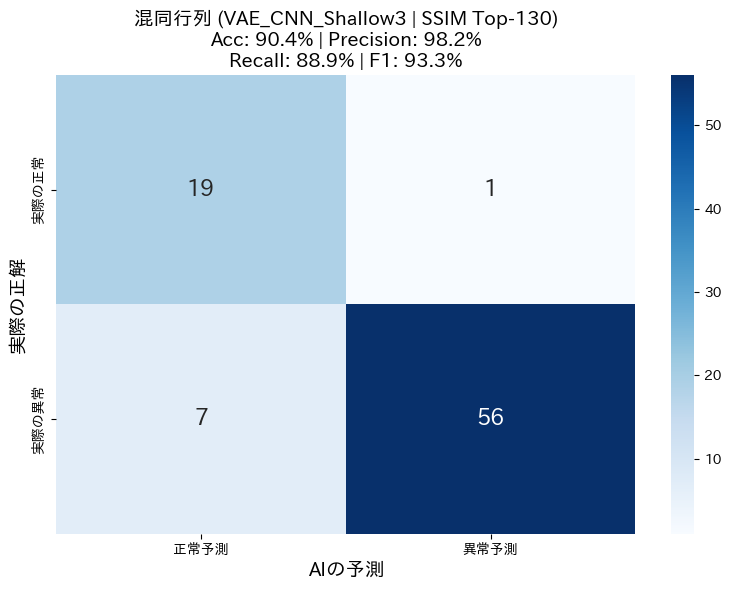

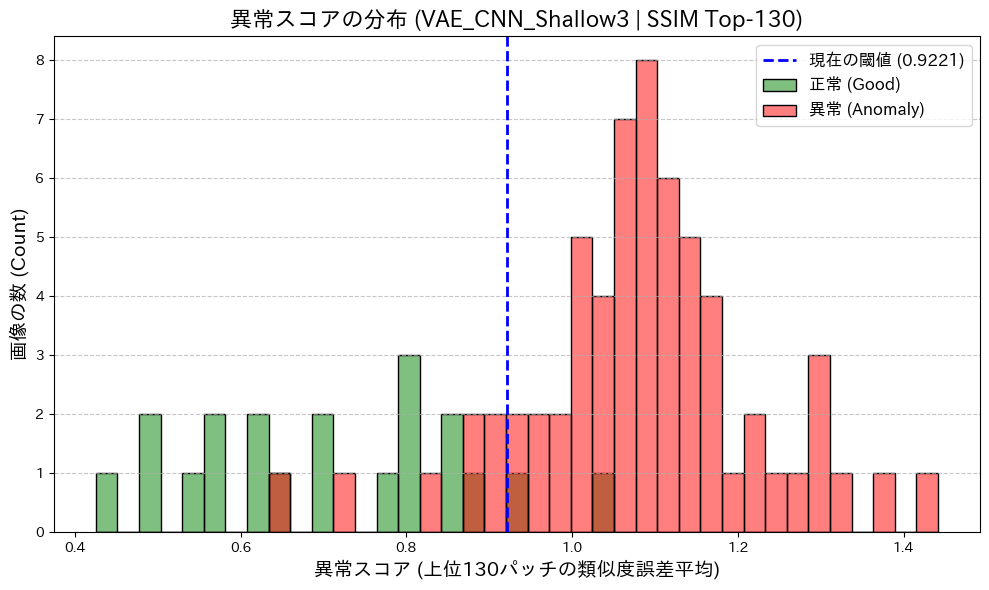

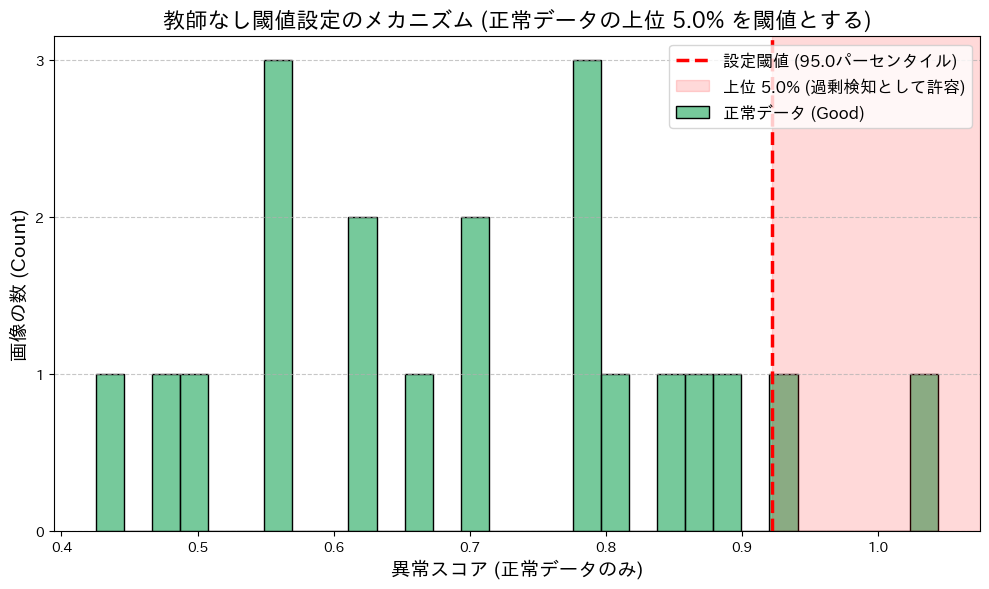


--- パターン別の代表例を可視化します ---

【1. TN: 正常を「正常」と正しく判断】 : 該当 19 件中 2 件を表示


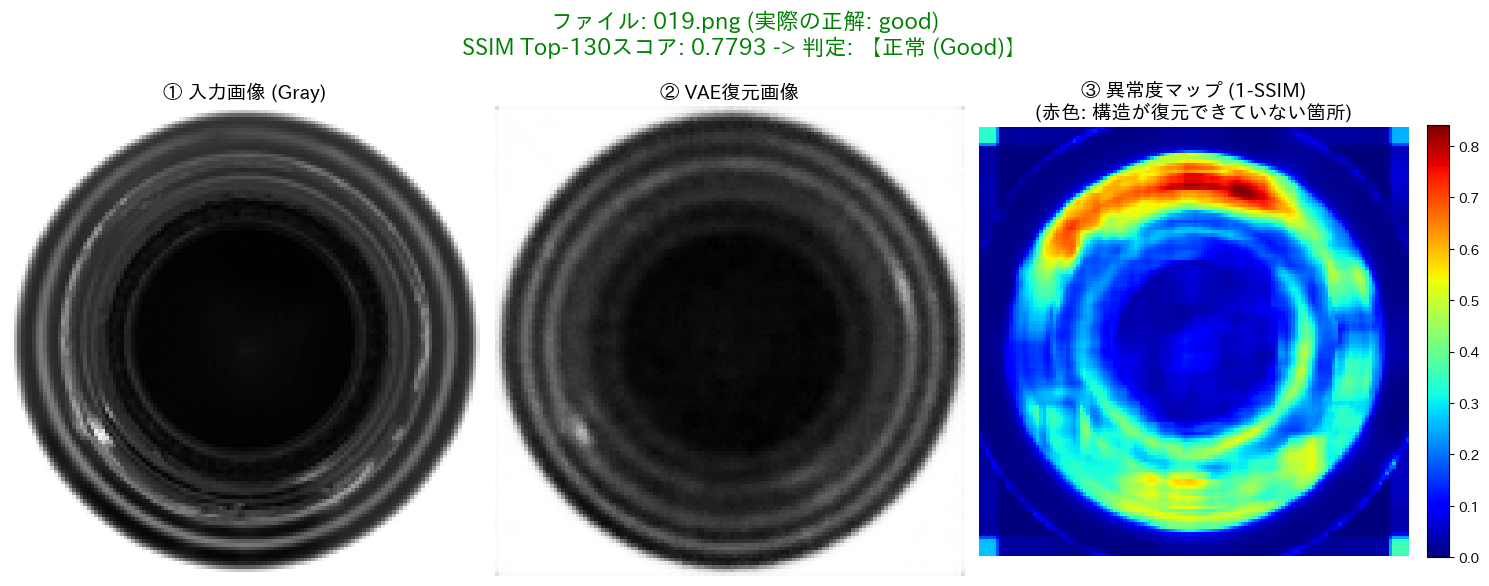

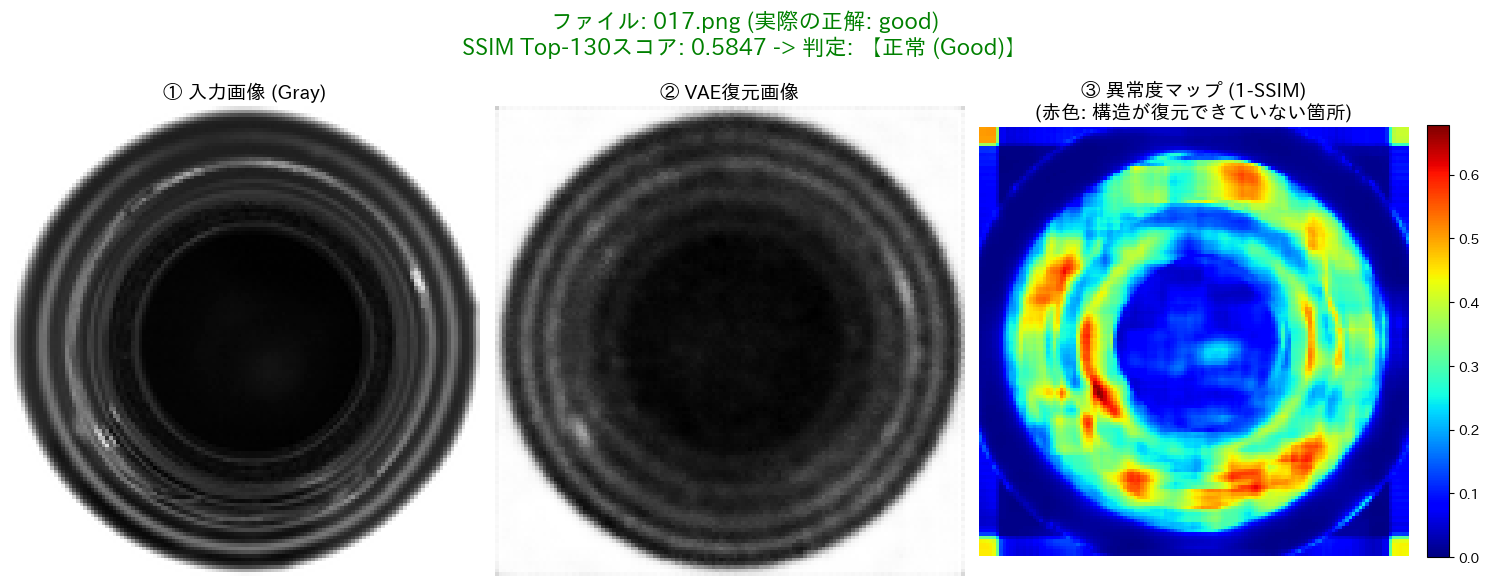


【2. FP: 正常を「異常」と誤って判断 (過剰検知)】 : 該当 1 件中 1 件を表示


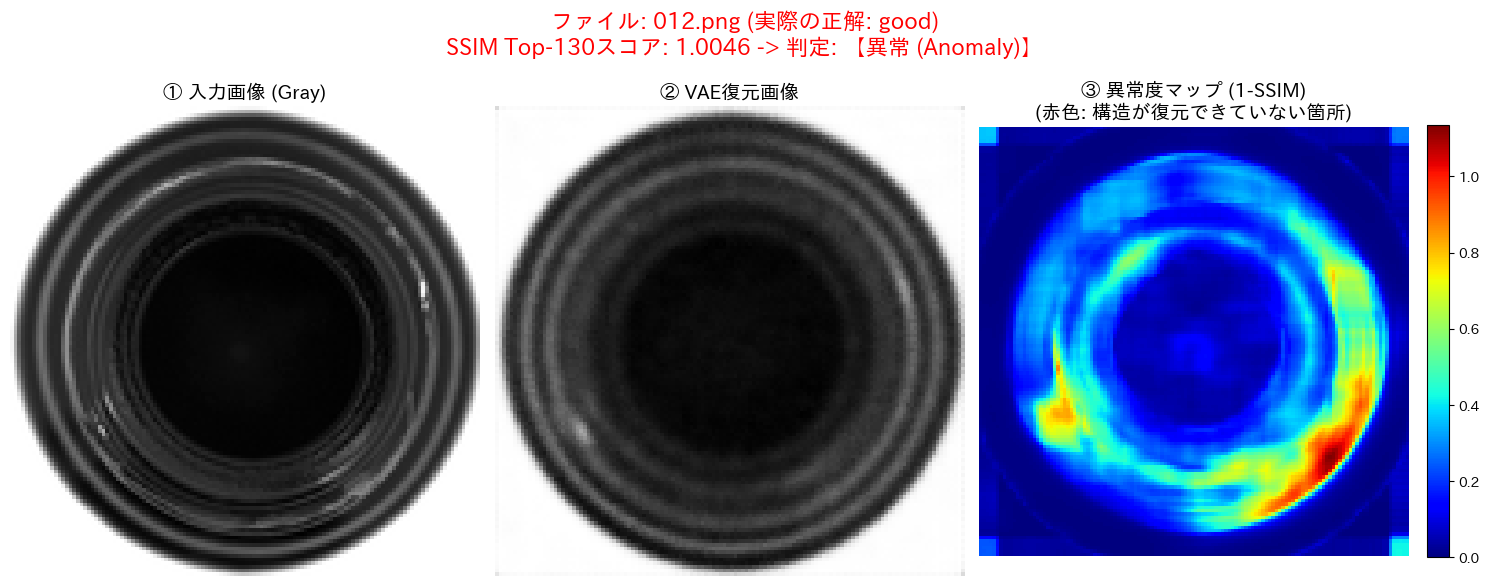


【3. FN: 異常を「正常」と誤って判断 (見逃し)】 : 該当 7 件中 2 件を表示


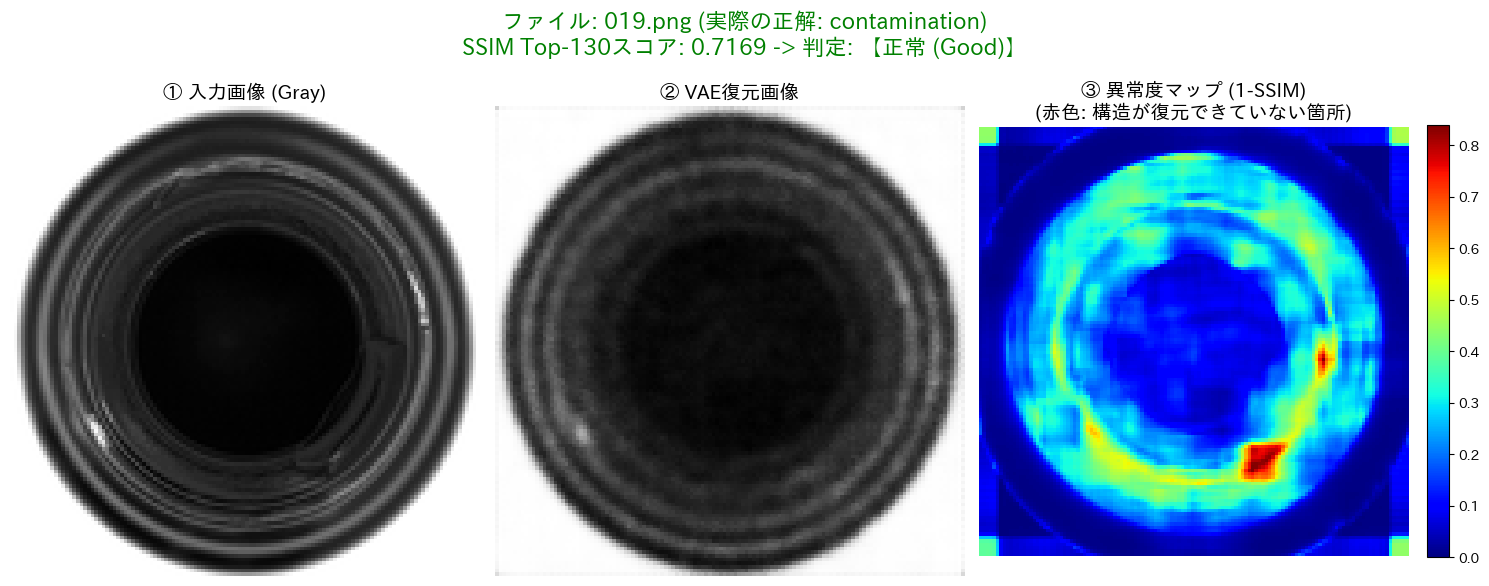

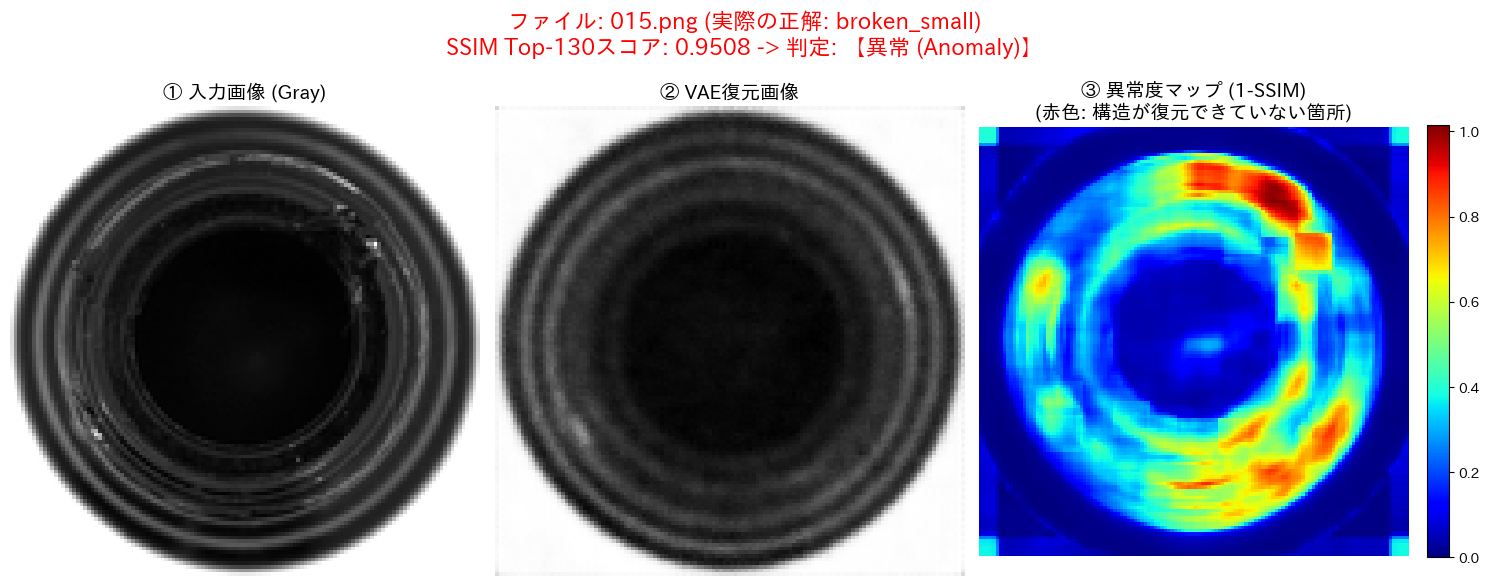


【4. TP: 異常を「異常」と正しく判断】 : 該当 56 件中 2 件を表示


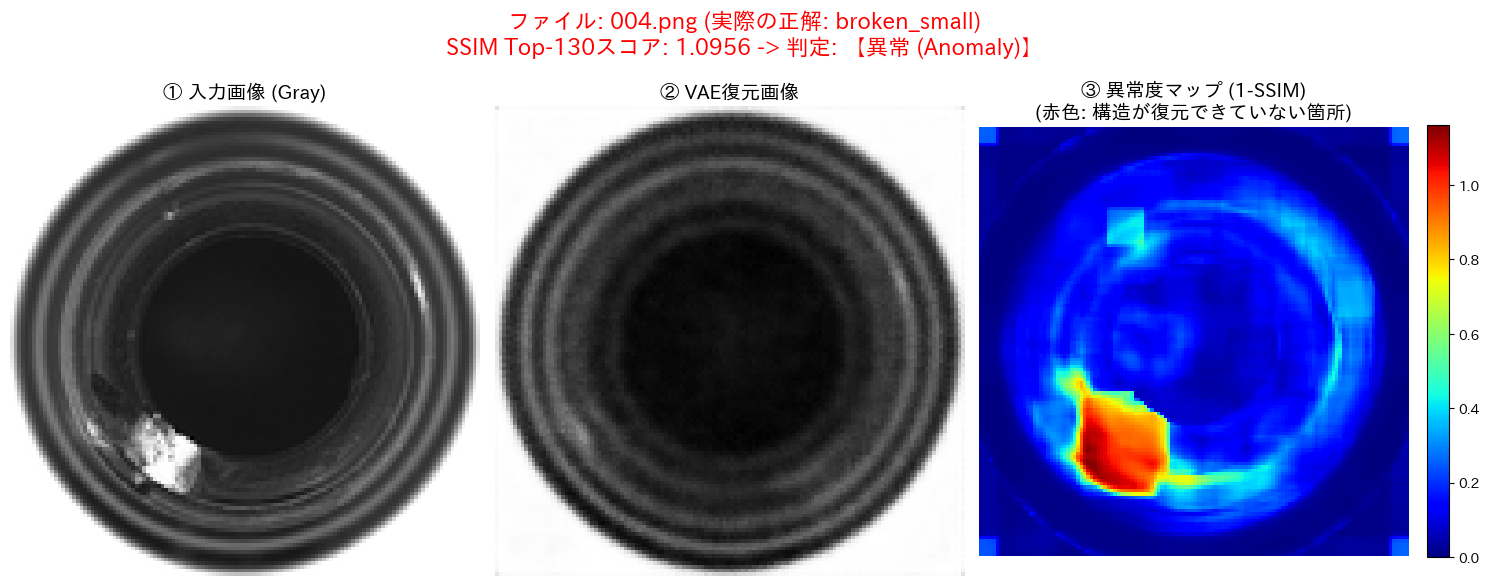

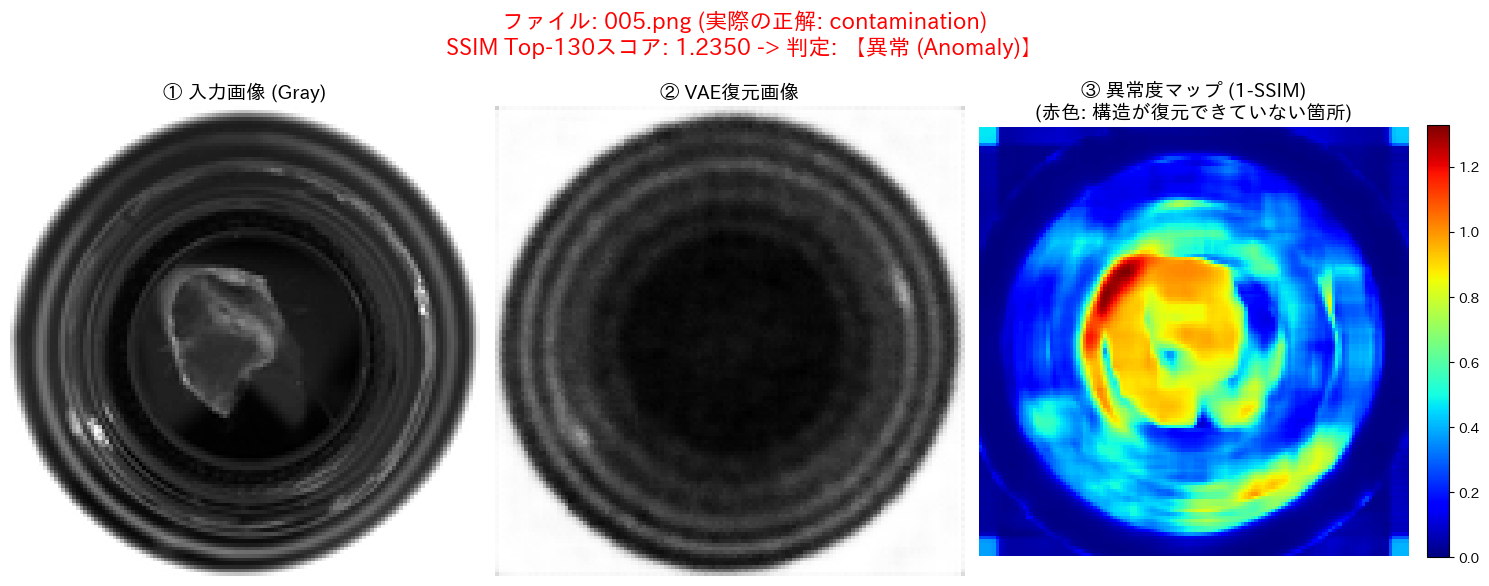


すべての検証プロセスが完了しました。


In [13]:
# =====================================================================
# 検証用コード: 浅いCNNモデル（VAE_CNN_Shallow3） 専用
# 異常スコア: SSIM Top-K (上位130パッチの平均誤差)
# 閾値設定: 教師なし (パーセンタイル法)
# =====================================================================
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score
import random
from skimage.metrics import structural_similarity as ssim
import matplotlib.ticker as ticker

# 文字化け対策の強制適用
import japanize_matplotlib
japanize_matplotlib.japanize()

# =====================================================================
# 1. 前処理とモデルの定義 (VAE_CNN_Shallow3版)
# =====================================================================
transform = transforms.Compose([
    transforms.CenterCrop(820),
    transforms.Resize((128, 128), interpolation=transforms.InterpolationMode.LANCZOS),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
])

# 検証対象のモデルクラス定義
class VAE_CNN_Shallow3(nn.Module):
    def __init__(self, latent_dim=64):
        super(VAE_CNN_Shallow3, self).__init__()
        
        # エンコーダ: 畳み込み層で空間情報を保ちながら圧縮 (128 -> 64 -> 32 -> 16)
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            
            nn.Conv2d(16, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        
        # 64チャンネル * 16 * 16 = 16384次元
        self.fc_mu = nn.Linear(64 * 16 * 16, latent_dim)
        self.fc_logvar = nn.Linear(64 * 16 * 16, latent_dim)
        
        self.decoder_fc = nn.Linear(latent_dim, 64 * 16 * 16)
        
        # デコーダ: 逆畳み込み層で元の画像サイズへ復元
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            
            nn.ConvTranspose2d(16, 1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        h = self.encoder_conv(x)
        h = torch.flatten(h, start_dim=1)
        
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        logvar = torch.clamp(logvar, min=-10.0, max=10.0) # ★安全装置
        
        std = torch.exp(0.5 * logvar)
        z = mu + torch.randn_like(std) * std
        
        h_recon = self.decoder_fc(z)
        h_recon = h_recon.view(-1, 64, 16, 16) # 4階テンソルに戻す
        recon = self.decoder_conv(h_recon)
        
        return recon, mu, logvar

# =====================================================================
# 2. 評価と可視化の関数群
# =====================================================================
def evaluate_dataset(model, test_dir, device, top_k=130):
    model.eval()
    y_true, scores, all_image_paths = [], [], [] 
    
    test_dir = Path(test_dir)
    if not test_dir.exists():
        raise FileNotFoundError(f"テストディレクトリが見つかりません: {test_dir}\nデータパスを確認してください。")

    print(f"テストデータ全件の評価を開始します... (モデル: VAE_CNN_Shallow3, Top-K: {top_k})")
    
    with torch.no_grad():
        for folder in test_dir.iterdir():
            if not folder.is_dir():
                continue
                
            true_label = 0 if folder.name == "good" else 1
            img_paths = list(folder.glob("*.png"))
            if not img_paths:
                continue

            for img_path in img_paths:
                img = Image.open(img_path).convert('RGB')
                input_tensor = transform(img).unsqueeze(0).to(device)

                recon_tensor, _, _ = model(input_tensor)
                input_img = input_tensor.squeeze().cpu().numpy()
                recon_img = recon_tensor.squeeze().cpu().numpy()

                _, ssim_map = ssim(input_img, recon_img, data_range=1.0, win_size=11, full=True)
                anomaly_map = 1.0 - ssim_map

                sorted_anomaly = np.sort(anomaly_map.flatten())[::-1]
                top_k_score = np.mean(sorted_anomaly[:top_k])

                y_true.append(true_label)
                scores.append(top_k_score)
                all_image_paths.append(img_path)

    print("評価が完了しました。")
    return np.array(y_true), np.array(scores), all_image_paths

def plot_confusion_matrix(y_true, y_pred, threshold, top_k=130):
    acc = accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"\n--- 定量評価結果 (VAE_CNN_Shallow3) ---")
    print(f"設定閾値: {threshold:.4f}")
    print(f"正解率 (Accuracy)  : {acc * 100:.2f}%")
    print(f"適合率 (Precision) : {precision * 100:.2f}%")
    print(f"再現率 (Recall)    : {recall * 100:.2f}%")
    print(f"F値 (F1-score)     : {f1 * 100:.2f}%\n")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['正常予測', '異常予測'],
                yticklabels=['実際の正常', '実際の異常'],
                annot_kws={"size": 16})

    title_str = (f"混同行列 (VAE_CNN_Shallow3 | SSIM Top-{top_k})\n"
                 f"Acc: {acc*100:.1f}% | Precision: {precision*100:.1f}%\n"
                 f"Recall: {recall*100:.1f}% | F1: {f1*100:.1f}%")
    
    plt.title(title_str, fontsize=14)
    plt.xlabel('AIの予測', fontsize=14)
    plt.ylabel('実際の正解', fontsize=14)
    plt.tight_layout()
    plt.show()

def plot_score_distribution(y_true, scores, threshold, top_k=130):
    plt.figure(figsize=(10, 6))

    normal_scores = scores[y_true == 0]
    anomaly_scores = scores[y_true == 1]

    min_score = np.min(scores)
    max_score = np.max(scores)
    common_bins = np.linspace(min_score, max_score, 40)

    sns.histplot(normal_scores, bins=common_bins, color='green', alpha=0.5, label='正常 (Good)', kde=False)
    sns.histplot(anomaly_scores, bins=common_bins, color='red', alpha=0.5, label='異常 (Anomaly)', kde=False)

    plt.axvline(x=threshold, color='blue', linestyle='--', linewidth=2, label=f'現在の閾値 ({threshold:.4f})')

    plt.title(f"異常スコアの分布 (VAE_CNN_Shallow3 | SSIM Top-{top_k})", fontsize=16, fontweight='bold')
    plt.xlabel(f"異常スコア (上位{top_k}パッチの類似度誤差平均)", fontsize=14)
    plt.ylabel("画像の数 (Count)", fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

def plot_unsupervised_threshold(y_true, scores, threshold, percentile=95.0):
    plt.figure(figsize=(10, 6))

    normal_scores = scores[y_true == 0]
    sns.histplot(normal_scores, bins=30, color='mediumseagreen', alpha=0.7,  label='正常データ (Good)')
    plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    plt.axvline(x=threshold, color='red', linestyle='--', linewidth=2.5, label=f'設定閾値 ({percentile}パーセンタイル)')

    x_min, x_max = plt.xlim()
    plt.axvspan(threshold, x_max, color='red', alpha=0.15, label=f'上位 {100-percentile:.1f}% (過剰検知として許容)')
    plt.xlim(x_min, x_max) 

    plt.title(f"教師なし閾値設定のメカニズム (正常データの上位 {100-percentile:.1f}% を閾値とする)", fontsize=16, fontweight='bold')
    plt.xlabel("異常スコア (正常データのみ)", fontsize=14)
    plt.ylabel("画像の数 (Count)", fontsize=14)
    plt.legend(fontsize=12, loc='upper right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

def plot_single_anomaly(model, image_path, device, threshold, top_k=130):
    model.eval()
    img = Image.open(image_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        recon_tensor, _, _ = model(input_tensor)

    input_img = input_tensor.squeeze().cpu().numpy()
    recon_img = recon_tensor.squeeze().cpu().numpy()

    _, ssim_map = ssim(input_img, recon_img, data_range=1.0, win_size=11, full=True)
    anomaly_map = 1.0 - ssim_map
    sorted_anomaly = np.sort(anomaly_map.flatten())[::-1]
    top_k_score = np.mean(sorted_anomaly[:top_k])

    is_anomaly = top_k_score > threshold
    judgment = "【異常 (Anomaly)】" if is_anomaly else "【正常 (Good)】"
    result_color = 'red' if is_anomaly else 'green'

    fig, axes = plt.subplots(1, 3, figsize=(15, 6))
    fig.suptitle(f"ファイル: {image_path.name} (実際の正解: {image_path.parent.name})\nSSIM Top-{top_k}スコア: {top_k_score:.4f} -> 判定: {judgment}",
                 fontsize=16, fontweight='bold', color=result_color)

    axes[0].imshow(input_img, cmap='gray')
    axes[0].set_title("① 入力画像 (Gray)", fontsize=14)
    axes[0].axis('off')

    axes[1].imshow(recon_img, cmap='gray')
    axes[1].set_title("② VAE復元画像", fontsize=14)
    axes[1].axis('off')

    vmax_val = np.max(anomaly_map) if np.max(anomaly_map) > 0.1 else 0.1
    im3 = axes[2].imshow(anomaly_map, cmap='jet', vmin=0, vmax=vmax_val)
    axes[2].set_title(f"③ 異常度マップ (1-SSIM)\n(赤色: 構造が復元できていない箇所)", fontsize=14)
    axes[2].axis('off')
    fig.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

def compute_unsupervised_threshold(y_true, scores, method="percentile", k=3.0, percentile=95.0):
    normal_scores = scores[y_true == 0]
    
    if method == "sigma":
        mu = np.mean(normal_scores)
        sigma = np.std(normal_scores)
        threshold = mu + k * sigma
        print(f"\n[教師なししきい値設定: {k}σ法]")
        print(f"-> 正常データの平均(μ): {mu:.4f}, 標準偏差(σ): {sigma:.4f}")
        print(f"-> 最適しきい値: {threshold:.4f}")
        
    elif method == "percentile":
        threshold = np.percentile(normal_scores, percentile, method='lower')
        print(f"\n[教師なししきい値設定: パーセンタイル法 ({percentile}%)]")
        print(f"-> 正常データの {percentile}% を正常とみなす")
        print(f"-> 最適しきい値: {threshold:.4f}")
        
    return threshold

# =====================================================================
# 3. 実行ブロック
# =====================================================================
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"使用デバイス: {device}")

    model = VAE_CNN_Shallow3(latent_dim=64).to(device)
    
    # ★ ここを実際の浅いCNNモデルの重みファイル名に変更してください ★
    MODEL_PATH = "/home/okoshi/my_GItHub/image-anomaly-detection/saved_models/vae_CNN_Shallow3_Annealing_ep100_beta50_128.pth"

    if not Path(MODEL_PATH).exists():
        raise FileNotFoundError(f"重みファイルが見つかりません: {MODEL_PATH}\n学習が完了しているか、パスが正しいか確認してください。")

    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    print(f"VAE_CNN_Shallow3 の重みを読み込みました。\n")

    TEST_DIR = "/home/okoshi/my_GItHub/image-anomaly-detection/data/bottle/test"
    TOP_K = 130
    PERCENTILE_VAL = 95.0 

    # 1. 全画像の異常スコアを算出
    y_true, scores, all_image_paths = evaluate_dataset(model, TEST_DIR, device, top_k=TOP_K)

    # 2. 正常データのみの分布で閾値を自動計算
    THRESHOLD = compute_unsupervised_threshold(y_true, scores, method="percentile", percentile=PERCENTILE_VAL)

    # 3. 予測ラベルを作成
    y_pred = (scores > THRESHOLD).astype(int)

    # 4. グラフの描画
    plot_confusion_matrix(y_true, y_pred, THRESHOLD, top_k=TOP_K)
    plot_score_distribution(y_true, scores, THRESHOLD, top_k=TOP_K)
    plot_unsupervised_threshold(y_true, scores, THRESHOLD, percentile=PERCENTILE_VAL)

    print("\n--- パターン別の代表例を可視化します ---")
    tn_paths, fp_paths, fn_paths, tp_paths = [], [], [], []
    for true_lbl, pred_lbl, path in zip(y_true, y_pred, all_image_paths):
        if true_lbl == 0 and pred_lbl == 0: tn_paths.append(path)
        elif true_lbl == 0 and pred_lbl == 1: fp_paths.append(path)
        elif true_lbl == 1 and pred_lbl == 0: fn_paths.append(path)
        elif true_lbl == 1 and pred_lbl == 1: tp_paths.append(path)

    categories = {
        "【1. TN: 正常を「正常」と正しく判断】": tn_paths,
        "【2. FP: 正常を「異常」と誤って判断 (過剰検知)】": fp_paths,
        "【3. FN: 異常を「正常」と誤って判断 (見逃し)】": fn_paths,
        "【4. TP: 異常を「異常」と正しく判断】": tp_paths
    }

    for title, paths in categories.items():
        sample_size = min(2, len(paths))
        print(f"\n{title} : 該当 {len(paths)} 件中 {sample_size} 件を表示")

        if sample_size > 0:
            sampled_paths = random.sample(paths, sample_size)
            for img_path in sampled_paths:
                plot_single_anomaly(model, img_path, device, THRESHOLD, top_k=TOP_K)
        else:
            print("  -> このパターンに該当する画像はありません。")

    print("\nすべての検証プロセスが完了しました。")

使用デバイス: cuda
VAE_CNN_Deep5 の重みを読み込みました。

テストデータ全件の評価を開始します... (モデル: VAE_CNN_Deep5, Top-K: 130)
評価が完了しました。

[教師なししきい値設定: パーセンタイル法 (95.0%)]
-> 正常データの 95.0% を正常とみなす
-> 最適しきい値: 0.9660

--- 定量評価結果 (VAE_CNN_Deep5) ---
設定閾値: 0.9660
正解率 (Accuracy)  : 87.95%
適合率 (Precision) : 98.18%
再現率 (Recall)    : 85.71%
F値 (F1-score)     : 91.53%



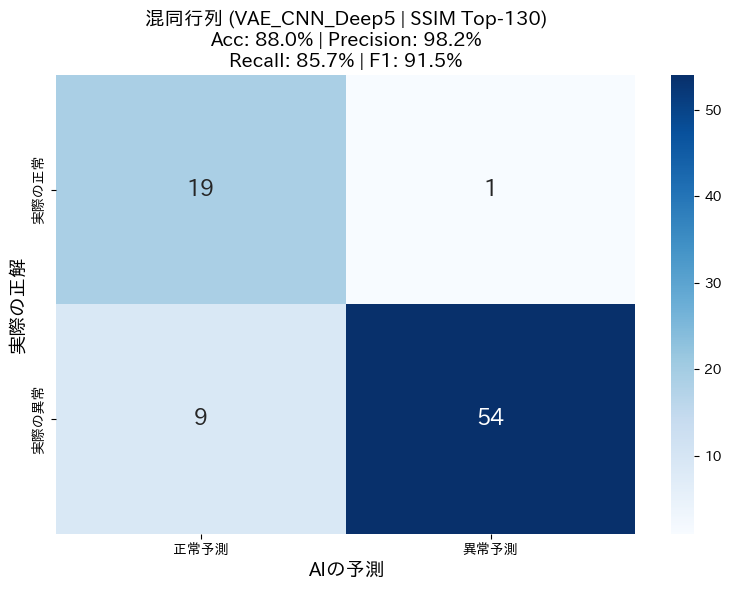

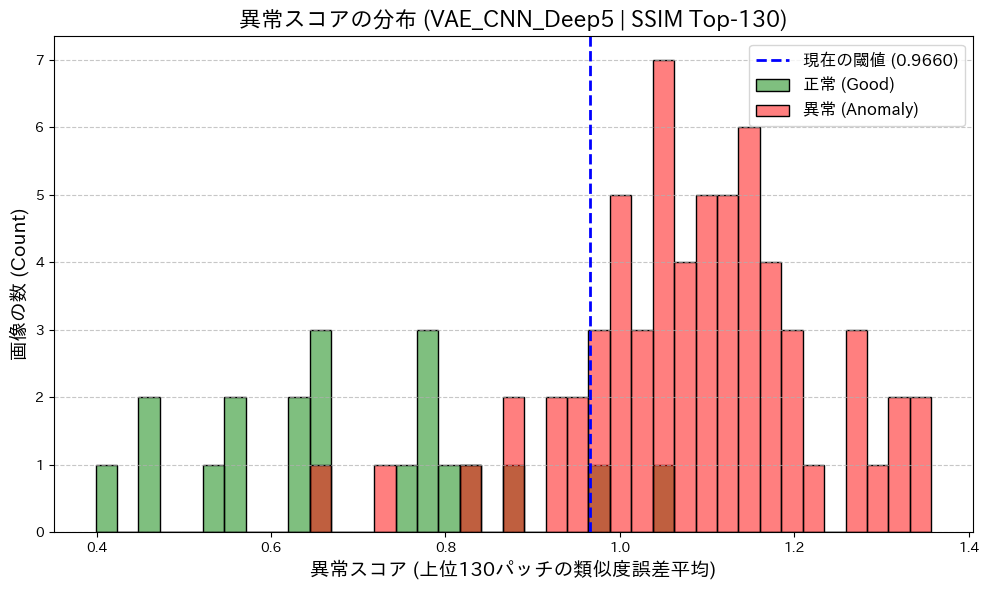

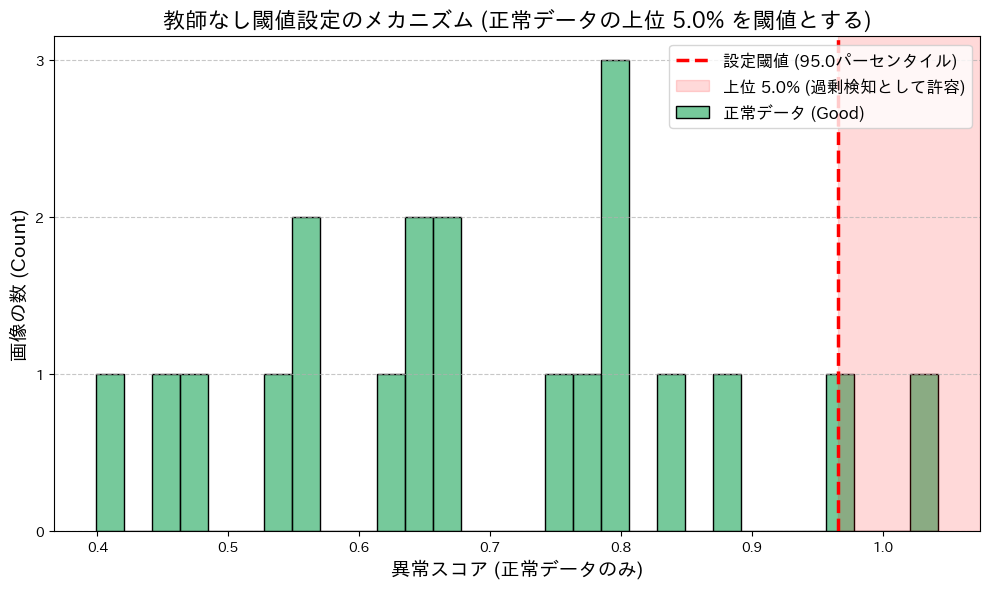


--- パターン別の代表例を可視化します ---

【1. TN: 正常を「正常」と正しく判断】 : 該当 19 件中 2 件を表示


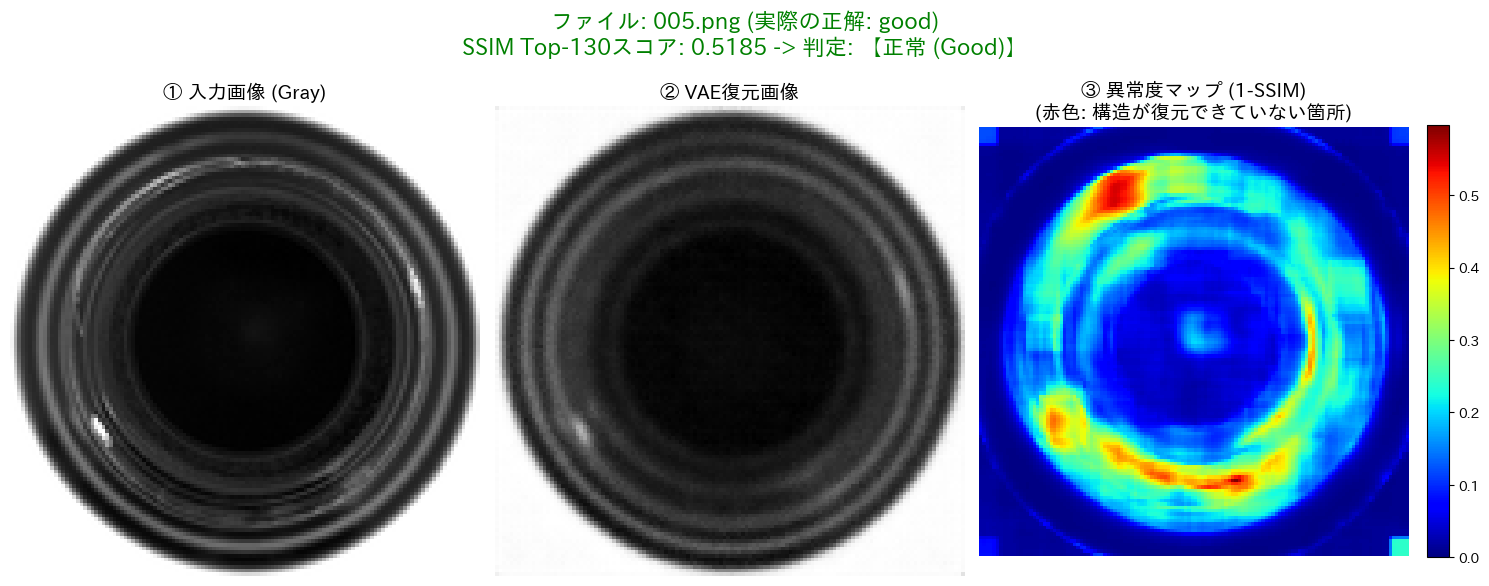

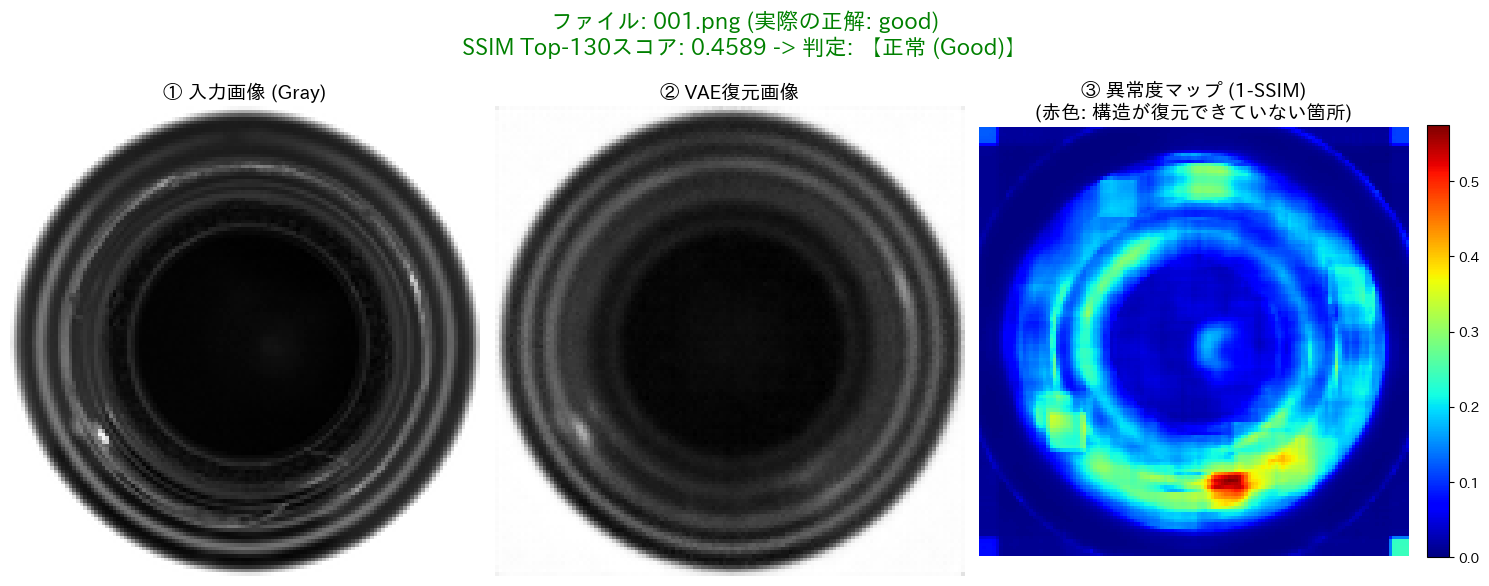


【2. FP: 正常を「異常」と誤って判断 (過剰検知)】 : 該当 1 件中 1 件を表示


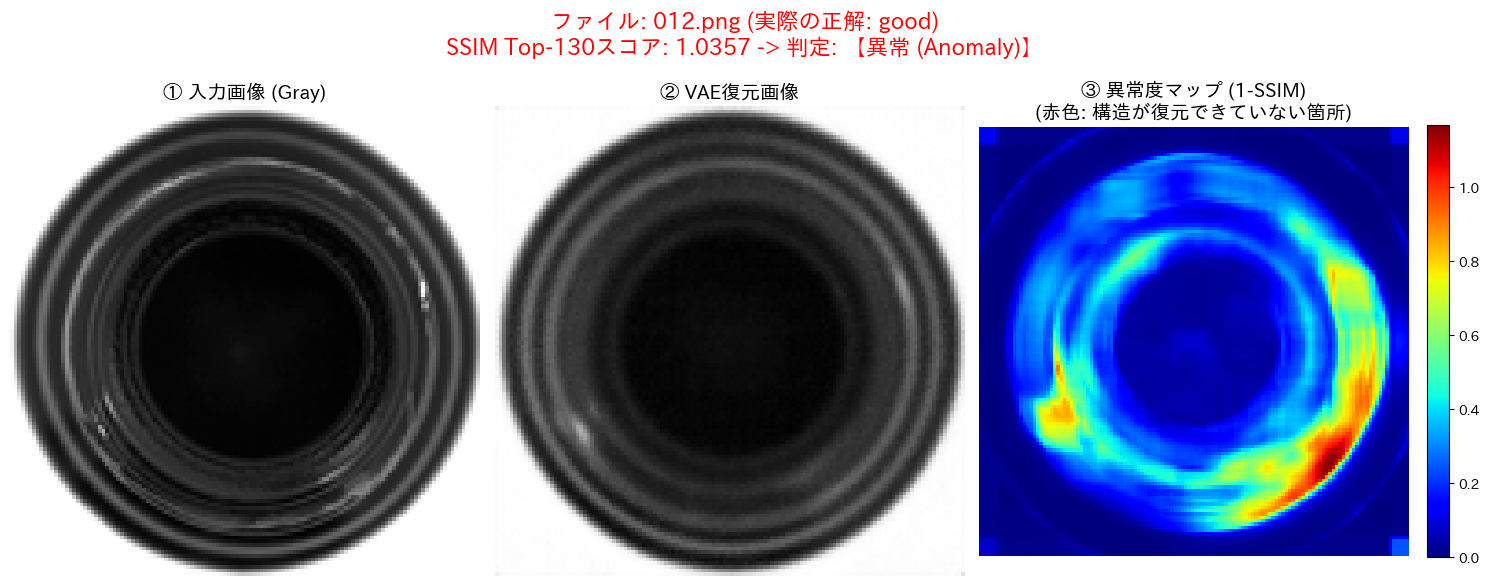


【3. FN: 異常を「正常」と誤って判断 (見逃し)】 : 該当 9 件中 2 件を表示


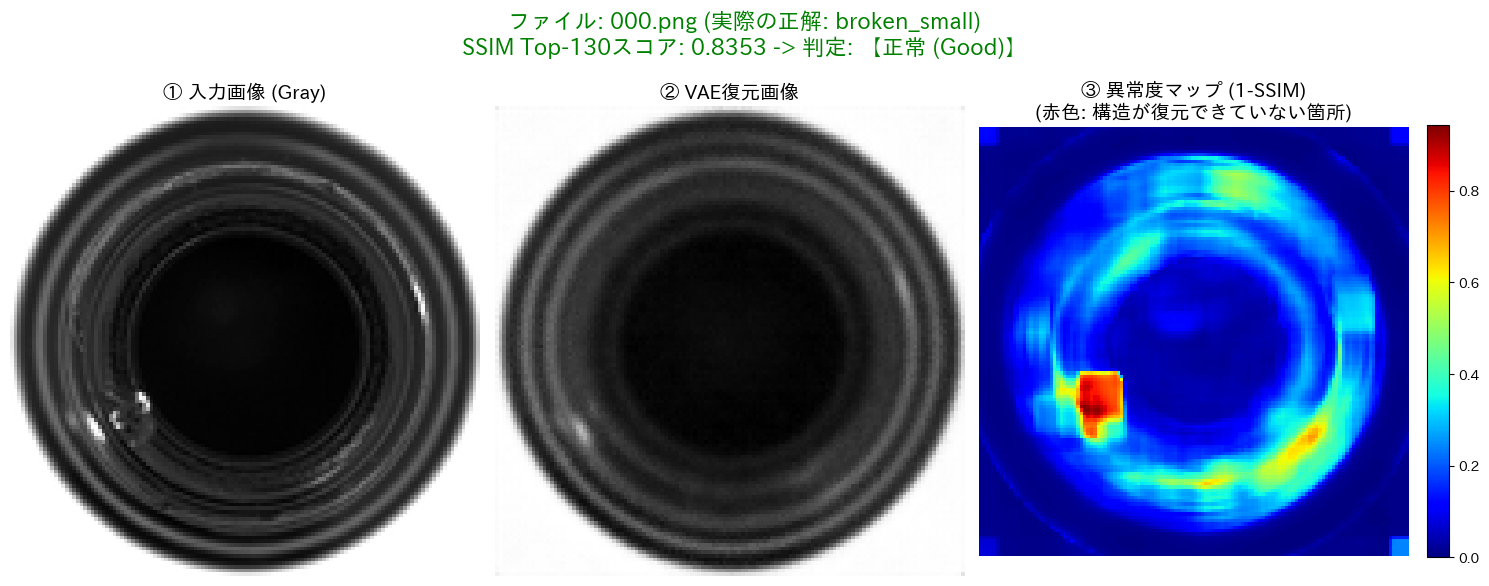

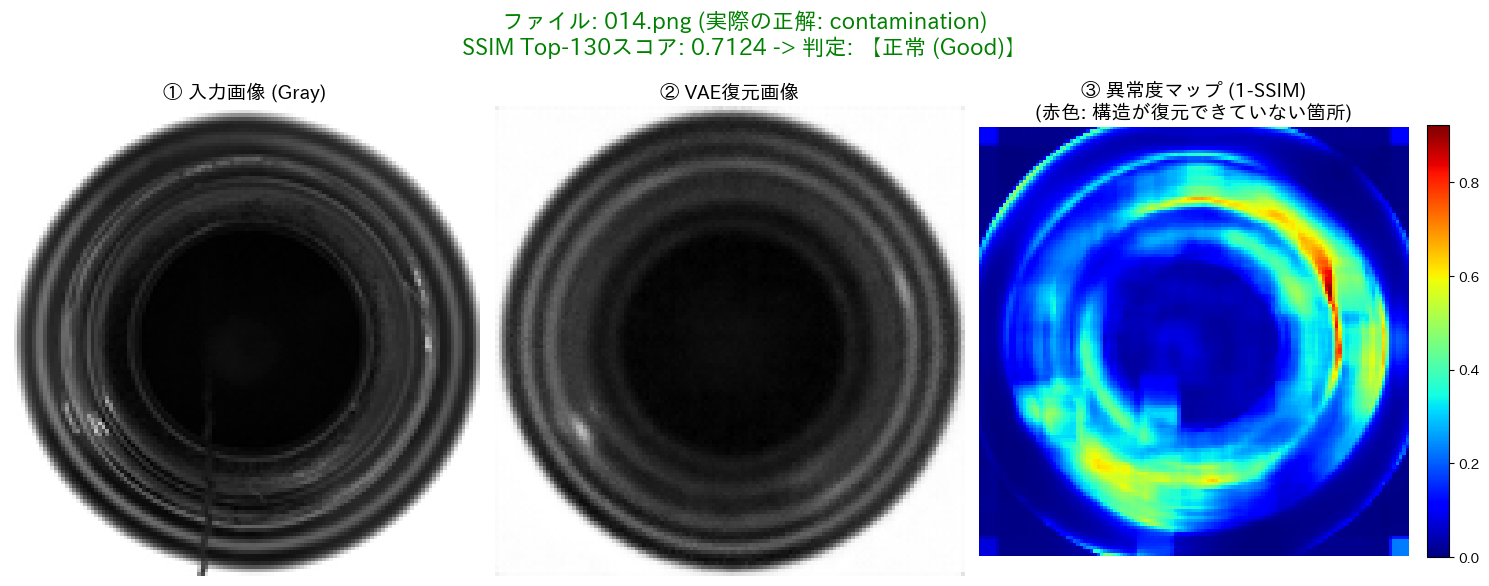


【4. TP: 異常を「異常」と正しく判断】 : 該当 54 件中 2 件を表示


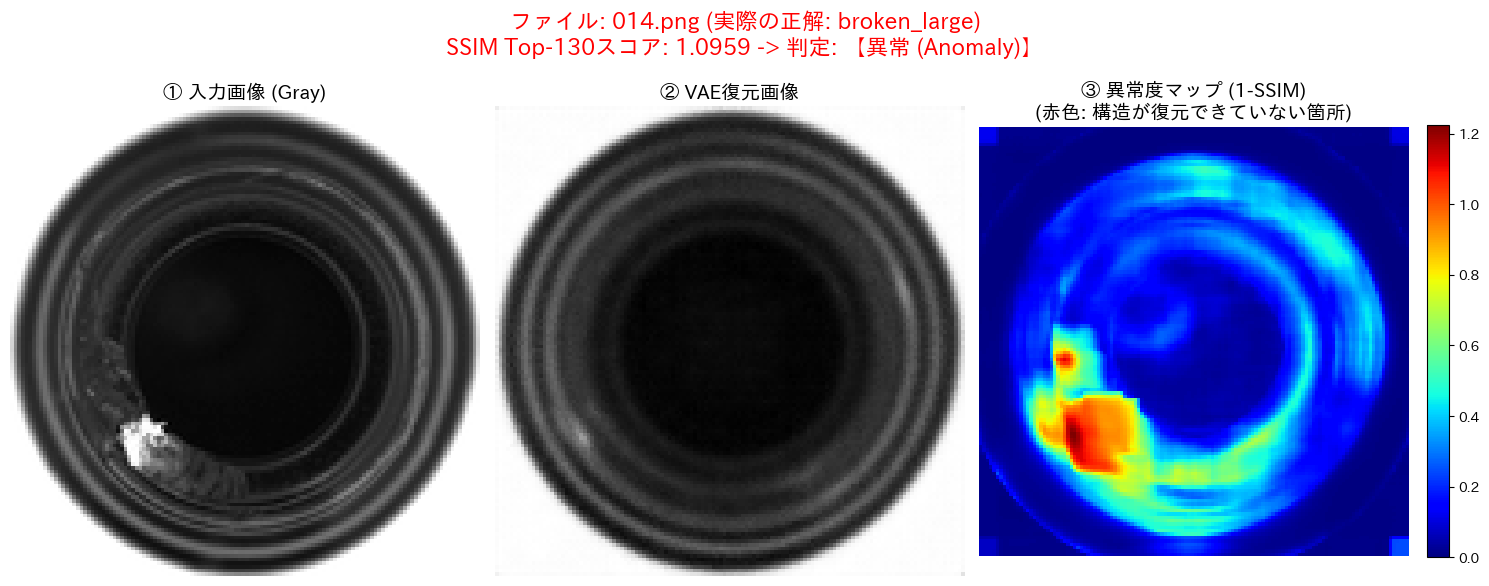

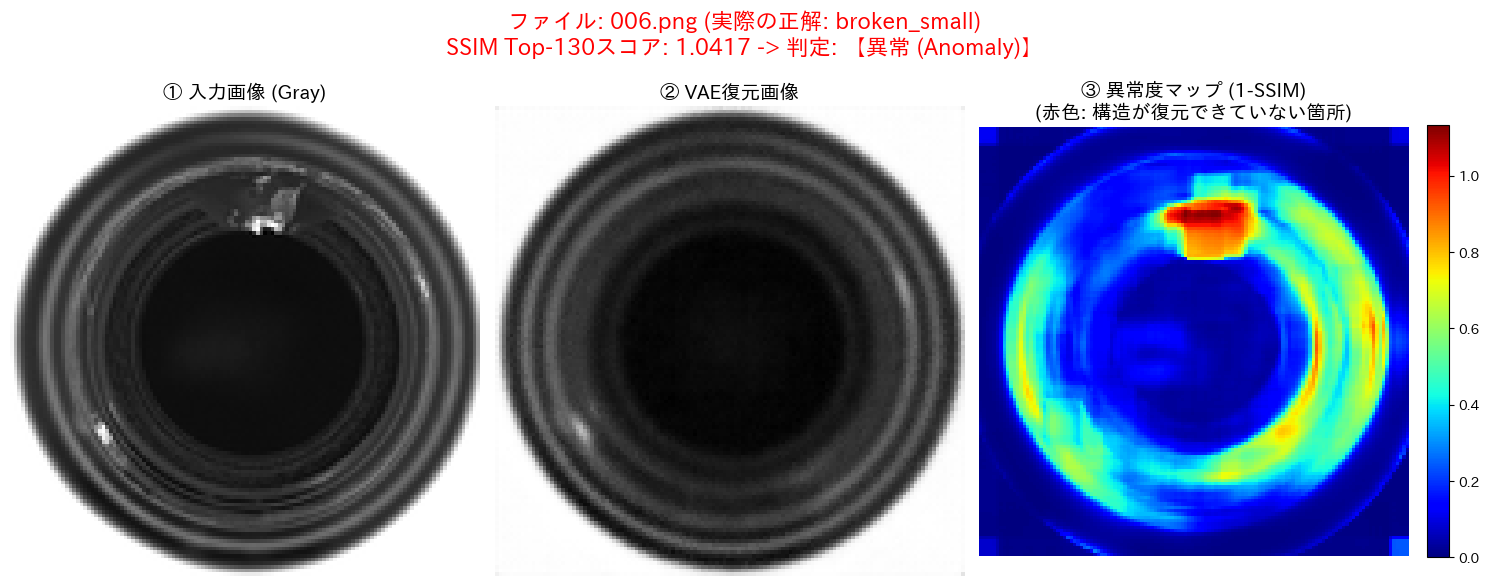


すべての検証プロセスが完了しました。


In [ ]:
# =====================================================================
# 検証用コード: 深いCNNモデル（VAE_CNN_Deep5） 専用
# 異常スコア: SSIM Top-K (上位130パッチの平均誤差)
# 閾値設定: 教師なし (パーセンタイル法)
# =====================================================================
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score
import random
from skimage.metrics import structural_similarity as ssim
import matplotlib.ticker as ticker

# 文字化け対策の強制適用
import japanize_matplotlib
japanize_matplotlib.japanize()

# =====================================================================
# 1. 前処理とモデルの定義 (VAE_CNN_Deep5版)
# =====================================================================
# 学習時と同じ前処理を定義
transform = transforms.Compose([
    transforms.CenterCrop(820),
    transforms.Resize((128, 128), interpolation=transforms.InterpolationMode.LANCZOS),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
])

# 検証対象のモデルクラス定義
class VAE_CNN_Deep5(nn.Module):
    def __init__(self, latent_dim=64):
        super(VAE_CNN_Deep5, self).__init__()
        
        # エンコーダ: 畳み込み層を5層重ねてさらに深く圧縮 (128 -> 64 -> 32 -> 16 -> 8 -> 4)
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            
            nn.Conv2d(16, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            # --- ここから追加した深い層 ---
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )
        
        # 最終層のサイズ: 256チャンネル * 4ピクセル * 4ピクセル = 4096次元
        self.fc_mu = nn.Linear(256 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(256 * 4 * 4, latent_dim)
        
        # デコーダ用の全結合層
        self.decoder_fc = nn.Linear(latent_dim, 256 * 4 * 4)
        
        # デコーダ: 逆畳み込み層を5層重ねて画像サイズを復元 (4 -> 8 -> 16 -> 32 -> 64 -> 128)
        self.decoder_conv = nn.Sequential(
            # --- ここから追加した深い層 ---
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            # ------------------------------

            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            
            nn.ConvTranspose2d(16, 1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        h = self.encoder_conv(x)
        h = torch.flatten(h, start_dim=1)
        
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        
        # ★重要: GPUでのKLD爆発を防ぐ安全装置
        logvar = torch.clamp(logvar, max=10.0)
        
        std = torch.exp(0.5 * logvar)
        z = mu + torch.randn_like(std) * std
        
        h_recon = self.decoder_fc(z)
        h_recon = h_recon.view(-1, 256, 4, 4) # 4階テンソルに戻す（256ch, 4x4）
        recon = self.decoder_conv(h_recon)
        
        return recon, mu, logvar

# =====================================================================
# 2. 評価と可視化の関数群
# =====================================================================
def evaluate_dataset(model, test_dir, device, top_k=130):
    model.eval()
    y_true, scores, all_image_paths = [], [], [] 
    
    test_dir = Path(test_dir)
    if not test_dir.exists():
        raise FileNotFoundError(f"テストディレクトリが見つかりません: {test_dir}\nデータパスを確認してください。")

    print(f"テストデータ全件の評価を開始します... (モデル: VAE_CNN_Deep5, Top-K: {top_k})")
    
    with torch.no_grad():
        for folder in test_dir.iterdir():
            if not folder.is_dir():
                continue
                
            true_label = 0 if folder.name == "good" else 1
            img_paths = list(folder.glob("*.png"))
            if not img_paths:
                continue

            for img_path in img_paths:
                img = Image.open(img_path).convert('RGB')
                input_tensor = transform(img).unsqueeze(0).to(device)

                recon_tensor, _, _ = model(input_tensor)
                input_img = input_tensor.squeeze().cpu().numpy()
                recon_img = recon_tensor.squeeze().cpu().numpy()

                _, ssim_map = ssim(input_img, recon_img, data_range=1.0, win_size=11, full=True)
                anomaly_map = 1.0 - ssim_map

                sorted_anomaly = np.sort(anomaly_map.flatten())[::-1]
                top_k_score = np.mean(sorted_anomaly[:top_k])

                y_true.append(true_label)
                scores.append(top_k_score)
                all_image_paths.append(img_path)

    print("評価が完了しました。")
    return np.array(y_true), np.array(scores), all_image_paths

def plot_confusion_matrix(y_true, y_pred, threshold, top_k=130):
    acc = accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"\n--- 定量評価結果 (VAE_CNN_Deep5) ---")
    print(f"設定閾値: {threshold:.4f}")
    print(f"正解率 (Accuracy)  : {acc * 100:.2f}%")
    print(f"適合率 (Precision) : {precision * 100:.2f}%")
    print(f"再現率 (Recall)    : {recall * 100:.2f}%")
    print(f"F値 (F1-score)     : {f1 * 100:.2f}%\n")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['正常予測', '異常予測'],
                yticklabels=['実際の正常', '実際の異常'],
                annot_kws={"size": 16})

    title_str = (f"混同行列 (VAE_CNN_Deep5 | SSIM Top-{top_k})\n"
                 f"Acc: {acc*100:.1f}% | Precision: {precision*100:.1f}%\n"
                 f"Recall: {recall*100:.1f}% | F1: {f1*100:.1f}%")
    
    plt.title(title_str, fontsize=14)
    plt.xlabel('AIの予測', fontsize=14)
    plt.ylabel('実際の正解', fontsize=14)
    plt.tight_layout()
    plt.show()

def plot_score_distribution(y_true, scores, threshold, top_k=130):
    plt.figure(figsize=(10, 6))

    normal_scores = scores[y_true == 0]
    anomaly_scores = scores[y_true == 1]

    min_score = np.min(scores)
    max_score = np.max(scores)
    common_bins = np.linspace(min_score, max_score, 40)

    sns.histplot(normal_scores, bins=common_bins, color='green', alpha=0.5, label='正常 (Good)', kde=False)
    sns.histplot(anomaly_scores, bins=common_bins, color='red', alpha=0.5, label='異常 (Anomaly)', kde=False)

    plt.axvline(x=threshold, color='blue', linestyle='--', linewidth=2, label=f'現在の閾値 ({threshold:.4f})')

    plt.title(f"異常スコアの分布 (VAE_CNN_Deep5 | SSIM Top-{top_k})", fontsize=16, fontweight='bold')
    plt.xlabel(f"異常スコア (上位{top_k}パッチの類似度誤差平均)", fontsize=14)
    plt.ylabel("画像の数 (Count)", fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

def plot_unsupervised_threshold(y_true, scores, threshold, percentile=95.0):
    plt.figure(figsize=(10, 6))

    normal_scores = scores[y_true == 0]
    sns.histplot(normal_scores, bins=30, color='mediumseagreen', alpha=0.7,  label='正常データ (Good)')
    plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    plt.axvline(x=threshold, color='red', linestyle='--', linewidth=2.5, label=f'設定閾値 ({percentile}パーセンタイル)')

    x_min, x_max = plt.xlim()
    plt.axvspan(threshold, x_max, color='red', alpha=0.15, label=f'上位 {100-percentile:.1f}% (過剰検知として許容)')
    plt.xlim(x_min, x_max) 

    plt.title(f"教師なし閾値設定のメカニズム (正常データの上位 {100-percentile:.1f}% を閾値とする)", fontsize=16, fontweight='bold')
    plt.xlabel("異常スコア (正常データのみ)", fontsize=14)
    plt.ylabel("画像の数 (Count)", fontsize=14)
    plt.legend(fontsize=12, loc='upper right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

def plot_single_anomaly(model, image_path, device, threshold, top_k=130):
    model.eval()
    img = Image.open(image_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        recon_tensor, _, _ = model(input_tensor)

    input_img = input_tensor.squeeze().cpu().numpy()
    recon_img = recon_tensor.squeeze().cpu().numpy()

    _, ssim_map = ssim(input_img, recon_img, data_range=1.0, win_size=11, full=True)
    anomaly_map = 1.0 - ssim_map
    sorted_anomaly = np.sort(anomaly_map.flatten())[::-1]
    top_k_score = np.mean(sorted_anomaly[:top_k])

    is_anomaly = top_k_score > threshold
    judgment = "【異常 (Anomaly)】" if is_anomaly else "【正常 (Good)】"
    result_color = 'red' if is_anomaly else 'green'

    fig, axes = plt.subplots(1, 3, figsize=(15, 6))
    fig.suptitle(f"ファイル: {image_path.name} (実際の正解: {image_path.parent.name})\nSSIM Top-{top_k}スコア: {top_k_score:.4f} -> 判定: {judgment}",
                 fontsize=16, fontweight='bold', color=result_color)

    axes[0].imshow(input_img, cmap='gray')
    axes[0].set_title("① 入力画像 (Gray)", fontsize=14)
    axes[0].axis('off')

    axes[1].imshow(recon_img, cmap='gray')
    axes[1].set_title("② VAE復元画像", fontsize=14)
    axes[1].axis('off')

    vmax_val = np.max(anomaly_map) if np.max(anomaly_map) > 0.1 else 0.1
    im3 = axes[2].imshow(anomaly_map, cmap='jet', vmin=0, vmax=vmax_val)
    axes[2].set_title(f"③ 異常度マップ (1-SSIM)\n(赤色: 構造が復元できていない箇所)", fontsize=14)
    axes[2].axis('off')
    fig.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

def compute_unsupervised_threshold(y_true, scores, method="percentile", k=3.0, percentile=95.0):
    normal_scores = scores[y_true == 0]
    
    if method == "sigma":
        mu = np.mean(normal_scores)
        sigma = np.std(normal_scores)
        threshold = mu + k * sigma
        print(f"\n[教師なししきい値設定: {k}σ法]")
        print(f"-> 正常データの平均(μ): {mu:.4f}, 標準偏差(σ): {sigma:.4f}")
        print(f"-> 最適しきい値: {threshold:.4f}")
        
    elif method == "percentile":
        threshold = np.percentile(normal_scores, percentile, method='lower')
        print(f"\n[教師なししきい値設定: パーセンタイル法 ({percentile}%)]")
        print(f"-> 正常データの {percentile}% を正常とみなす")
        print(f"-> 最適しきい値: {threshold:.4f}")
        
    return threshold

# =====================================================================
# 3. 実行ブロック
# =====================================================================
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"使用デバイス: {device}")

    model = VAE_CNN_Deep5(latent_dim=64).to(device)
    
    # ★ ここを実際の深いCNNモデルの重みファイル名に変更してください ★
    MODEL_PATH = "/home/okoshi/my_GItHub/image-anomaly-detection/saved_models/vae_CNN_Deep5_Annealing_ep100_beta50_128.pth"

    if not Path(MODEL_PATH).exists():
        raise FileNotFoundError(f"重みファイルが見つかりません: {MODEL_PATH}\n学習が完了しているか、パスが正しいか確認してください。")

    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    print(f"VAE_CNN_Deep5 の重みを読み込みました。\n")

    TEST_DIR = "/home/okoshi/my_GItHub/image-anomaly-detection/data/bottle/test"
    TOP_K = 130
    PERCENTILE_VAL = 95.0

    # 1. 全画像の異常スコアを算出
    y_true, scores, all_image_paths = evaluate_dataset(model, TEST_DIR, device, top_k=TOP_K)

    # 2. 正常データのみの分布で閾値を自動計算
    THRESHOLD = compute_unsupervised_threshold(y_true, scores, method="percentile", percentile=PERCENTILE_VAL)

    # 3. 予測ラベルを作成
    y_pred = (scores > THRESHOLD).astype(int)

    # 4. グラフの描画
    plot_confusion_matrix(y_true, y_pred, THRESHOLD, top_k=TOP_K)
    plot_score_distribution(y_true, scores, THRESHOLD, top_k=TOP_K)
    plot_unsupervised_threshold(y_true, scores, THRESHOLD, percentile=PERCENTILE_VAL)

    print("\n--- パターン別の代表例を可視化します ---")
    tn_paths, fp_paths, fn_paths, tp_paths = [], [], [], []
    for true_lbl, pred_lbl, path in zip(y_true, y_pred, all_image_paths):
        if true_lbl == 0 and pred_lbl == 0: tn_paths.append(path)
        elif true_lbl == 0 and pred_lbl == 1: fp_paths.append(path)
        elif true_lbl == 1 and pred_lbl == 0: fn_paths.append(path)
        elif true_lbl == 1 and pred_lbl == 1: tp_paths.append(path)

    categories = {
        "【1. TN: 正常を「正常」と正しく判断】": tn_paths,
        "【2. FP: 正常を「異常」と誤って判断 (過剰検知)】": fp_paths,
        "【3. FN: 異常を「正常」と誤って判断 (見逃し)】": fn_paths,
        "【4. TP: 異常を「異常」と正しく判断】": tp_paths
    }

    for title, paths in categories.items():
        sample_size = min(2, len(paths))
        print(f"\n{title} : 該当 {len(paths)} 件中 {sample_size} 件を表示")

        if sample_size > 0:
            sampled_paths = random.sample(paths, sample_size)
            for img_path in sampled_paths:
                plot_single_anomaly(model, img_path, device, THRESHOLD, top_k=TOP_K)
        else:
            print("  -> このパターンに該当する画像はありません。")

    print("\nすべての検証プロセスが完了しました。")